# Phase 0. Cleaning and Preparation

In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder

-------------------------------------------------

## 1. Introducción <a name="introduccion"></a>  

The dataset contains clinical and lifestyle information from 196 subjects. It includes demographic data, lifestyle habits, comorbidities, medication use, dental health, and saliva characteristics.

**Dataset Subsections**

* Lifestyle: Contains information about exercise habits, diet, smoking, caffeine, and alcohol consumption.

* Comorbidities: Includes the presence of various health conditions.

* Medication: Covers the use of immunosuppressants, corticosteroids, and other medications.

* Dental Health: Provides data on the number of teeth, dental conditions, and periodontal diagnosis.

* Saliva Characteristics: Describes saliva flow rates and pH levels.


## 1.1 Variable Descriptions


**Demographic Information**

* SubjectID: Unique identifier for each subject.

* Group: Classification of subjects into two cohorts:

    - sjj: Patients diagnosed with Sjögren's syndrome.

    - no-ssj: Patients not diagnosed with Sjögren's syndrome.

* Age: Age of the subject (range: 26 - 87).

* Menstrual_Status: Indicates whether a woman is premenopausal (Pre) or postmenopausal (Post).

* Genre: Gender of the subject (Female).


**Lifestyle Variables**

* Sport: Frequency of exercise:

    - 0 = Almost daily

    - 1 = 3 times/week

    - 2 = Occasional

    - 4 = Rarely

    - 5 = Never

* Meals/Day: Number of meals consumed per day.

* Diet: Type of diet followed:

    - 0 = Low fat

    - 1 = Low carbohydrate

    - 2 = Mediterranean

    - 3 = High-protein diet

    - 4 = Keto

    - 5 = Paleolithic diet

    - 6 = Vegetarian diet

    - 7 = Vegan diet

    - 8 = Others (e.g., diabetic, kidney protection, gluten-free, lactose-free, etc.)

* Sugar_Intake: Sugar consumption (0 = No, 1 = Yes).

* Sugar_Between_Meals: Sugar intake between meals (0 = No, 1 = Yes).

* Smoking: Smoking status (0 = No, 1 = Yes).

* Cigarettes/day: Number of cigarettes smoked per day (3 = Social smoker).

* Former_cigarettes/day: Whether the subject was a former smoker (0 = No, 1 = Yes).

* Caffeine: Caffeine consumption (0 = No, 1 = Yes).

* Caffeine/day: Caffeine intake per day (3 = Occasional).

* Alcohol_drinks: Alcohol consumption (0 = No, 1 = Yes).


**Comorbidities**

* Cardiovascular: Presence of cardiovascular conditions (0 = No, 1 = Yes).

* Neoplasia: Presence of neoplasia (0 = No, 1 = Yes).

* Gastrointestinal: Presence of gastrointestinal conditions (0 = No, 1 = Yes).

* Diabetes: Presence of diabetes (0 = No, 1 = Yes).

* Autoinmune: Presence of autoimmune diseases (0 = No, 1 = Yes).


**Medication Use**

* Immunosuppressants: Use of immunosuppressants (0 = No, 1 = Yes).

* Corticosteroids: Use of corticosteroids (0 = No, 1 = Yes).

* Another_medications: Other medications taken (e.g., aspirin).


**Dental Health**

* N_teeth: Total number of teeth (range: 0-28).

* Sound: Number of healthy teeth.

* Decay: Number of decayed teeth.

* Missing: Number of missing teeth.

* Filling: Number of dental fillings.

* CAO: CAO Index, the sum of decayed, missing, and filled teeth.

* Prosthesis: Presence of an oral prosthesis (0 = No, 1 = Yes).

* Periodontal_Diagnosis: Periodontal diagnosis based on the IPC index:

    - 0 = Healthy

    - 1 = Bleeding

    - 2 = Calculus

    - 3 = Pocket 4–5 mm

    - 4 = Pocket 6 mm or more

    - X = Excluded sextant

    - 9 = Not recorded
    

**Saliva Characteristics**

* pH: Stimulated saliva pH level.

* SA_Flow: Resting saliva flow per minute (Normal = 0.3/min).

* ST_Flow: Stimulated saliva flow per minute (Normal = 1.5/min).

* SA_Hyposalivation: Presence of hyposalivation in resting saliva (0 = No, 1 = Yes).

* ST_Hyposalivation: Presence of hyposalivation in stimulated saliva (0 = No, 1 = Yes).


-------------------------------------------------

## 2. Análisis Exploratorio de Datos <a name="analisis-exploratorio"></a>  

### 2.1. Descripción del Dataset <a name="descripcion-dataset"></a>  

In [127]:
db_ssj = pd.read_excel('./DB_SSJ_Menopausia_HypoSalMed.xlsx', skiprows=3)
db_ssj.head()

,SubjectID,Group,Age,Menstrual_status,Genre,Sport,Meals/day,Special_Diet,Sugar_Intake,Sugar_between meals,...,Missing,Filling,CAO,PROTESIS,IPC,N_Oral_mucosa disorder,SA_Flow (ml/min),SA_Hyposalivation,ST_Flow (ml/min),ST_Hyposalivation
0,SSVM001,sjj,60.0,Post,Female,2.0,2.0,2.0,0.0,0.0,...,5.0,10.0,16.0,0.0,3,0.0,0.008,1.0,0.9,1.0
1,SSVM002,sjj,42.0,Pre,Female,1.0,3.0,2.0,0.0,0.0,...,0.0,7.0,7.0,0.0,1,0.0,0.100,1.0,1.2,1.0
2,SSVM003,sjj,46.0,Pre,Female,3.0,4.0,2.0,1.0,1.0,...,2.0,16.0,18.0,0.0,3,0.0,0.130,1.0,0.8,1.0
3,SSVM004,sjj,70.0,Post,Female,3.0,4.0,2.0,1.0,1.0,...,28.0,0.0,28.0,1.0,X,0.0,0.200,1.0,0.6,1.0
4,SSVM005,sjj,48.0,NaN,Female,2.0,5.0,2.0,1.0,1.0,...,9.0,2.0,19.0,0.0,4,0.0,0.018,1.0,0.6,1.0


In [128]:
db_ssj.shape

(196, 38)

In [129]:
db_ssj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SubjectID               196 non-null    object 
 1   Group                   196 non-null    object 
 2   Age                     192 non-null    float64
 3   Menstrual_status        192 non-null    object 
 4   Genre                   192 non-null    object 
 5   Sport                   192 non-null    float64
 6   Meals/day               191 non-null    float64
 7   Special_Diet            188 non-null    float64
 8   Sugar_Intake            191 non-null    float64
 9   Sugar_between meals     188 non-null    float64
 10  Smoking                 192 non-null    float64
 11  Cigarettes/day          192 non-null    float64
 12  Former_cigarettes/day   191 non-null    float64
 13  Caffeine                191 non-null    float64
 14  Caffeine/day            190 non-null    fl

In [130]:
db_ssj.describe()

,Age,Sport,Meals/day,Special_Diet,Sugar_Intake,Sugar_between meals,Smoking,Cigarettes/day,Former_cigarettes/day,Caffeine,...,Decay,Missing,Filling,CAO,PROTESIS,N_Oral_mucosa disorder,SA_Flow (ml/min),SA_Hyposalivation,ST_Flow (ml/min),ST_Hyposalivation
count,192.000000,192.000000,191.000000,188.000000,191.000000,188.000000,192.000000,192.000000,191.000000,191.000000,...,189.000000,189.000000,189.000000,189.000000,195.000000,190.000000,194.000000,194.000000,195.000000,195.000000
mean,58.260417,1.765625,3.434555,1.962766,0.424084,0.287234,0.177083,1.916667,0.371728,0.675393,...,2.481481,6.730159,4.904762,14.116402,0.379487,0.194737,0.279485,0.618557,0.858297,0.825641
std,11.728379,1.641180,0.885354,1.157952,0.495502,0.453680,0.382737,5.042576,0.484536,0.469459,...,3.814296,7.290054,4.054342,7.276251,0.486508,0.481371,0.332140,0.486998,0.788273,0.380394
min,26.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2.000000,1.000000,9.000000,0.000000,0.000000,0.080000,0.000000,0.220000,1.000000
50%,58.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,4.000000,5.000000,13.000000,0.000000,0.000000,0.200000,1.000000,0.600000,1.000000
75%,67.000000,4.000000,4.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,4.000000,9.000000,8.000000,18.000000,1.000000,0.000000,0.357500,1.000000,1.330000,1.000000
max,94.000000,4.000000,5.000000,8.000000,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,...,19.000000,28.000000,16.000000,37.000000,1.000000,3.000000,2.100000,1.000000,5.000000,1.000000


Principales características que presenta el dataset:

* El número total de instancias del conjunto de datos es de 196.
* El número total de variables es de 37, siendo únicamente 7 de tipo object y el resto de tipo float64.
* El rango de edad de los pacientes va desde los 30 años hasta los 94.
* Todas las pacientes son mujeres (9 de cada 10 afectados, son mujeres).

In [131]:
for columna in db_ssj.columns:
    valores_unicos = db_ssj[columna].unique()
    print(f"Valores de la columna '{columna}':")
    print(valores_unicos)
    print()

Valores de la columna 'SubjectID':
['SSVM001' 'SSVM002' 'SSVM003' 'SSVM004' 'SSVM005' 'SSVM006' 'SSVM007'
 'SSVM008' 'SSVM009' 'SSVM012' 'SSVM013' 'SSVM014' 'SSVM015' 'SSVM016'
 'SSVM017' 'SSVM018' 'SSVM019' 'SSVM020' 'SSVM021' 'SSVM022' 'SSVM023'
 'SSVM024' 'SSVM025' 'SSVM026' 'SSVM027' 'SSVM028' 'SSVM029' 'SSVM030'
 'SSVM031' 'SSVM032' 'SSVM033' 'SSVM034' 'SSVM035' 'SSVM036' 'SSVM037'
 'SSVM038' 'SSVM039' 'SSVM040' 'SSVM041' 'SSVM042' 'SSVM043' 'SSVM044'
 'SSVM045' 'SSVM046' 'SSVM047' 'SSVM048' 'SSVM049' 'SSVM051' 'SSVM052'
 'SSVM053' 'SSVM054' 'SSVM055' 'SSVM056' 'SSVM057' 'SSVM058' 'SSVM059'
 'SSVM060' 'SSVM061' 'SSVM062' 'SSVM063' 'SSVM064' 'SSVM065' 'SSVM066'
 'SSVM067' 'SSVM068' 'SSVM069' 'SSVM070' 'SSVM071' 'SSVM072' 'SSVM073'
 'SSVM074' 'SSVM075' 'SSVM076' 'SSVM077' 'SSVM078' 'SSVM079' 'SSVM080'
 'SSVM081' 'SSVM083' 'SSVM084' 'SSVM085' 'SSVM086' 'SSVM087' 'SSVM088'
 'SSVM089' 'SSVM090' 'SSVM091' 'SSVM092' 'SSVM093' 'SSVM094' 'SSVM095'
 'SSVM096' 'SSVM097' 'SSVM098' 'SSVM099' '

In [132]:
CLASE = 'Group'

CONTINUOS = ['Age', 'Meals/day', 'Cigarettes/day', 'Former_cigarettes/day', 'Caffeine/day', 'N_Teeth', 
    'Sound', 'Decay', 'Missing ', 'Filling ', 
    'CAO', 'PROTESIS ', 'N_Oral_mucosa disorder', 'SA_Flow (ml/min)', 'ST_Flow (ml/min)']

DISCRETOS = ['Menstrual_status', 'Genre', 'Sport', 'Special_Diet', 'Sugar_Intake', 
    'Sugar_between meals', 'Smoking', 'Caffeine', 'Alcohol_drinks', 'Cardiovascular', 'Neoplasia', 
    'Gastrointestinal', 'Diabetes', 'Autoinmunes', 'Immunosuppressants', 'Corticosteroids', 'Hyposalivation',
    'Another_medications', 'IPC','SA_Hyposalivation', 'ST_Hyposalivation']

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


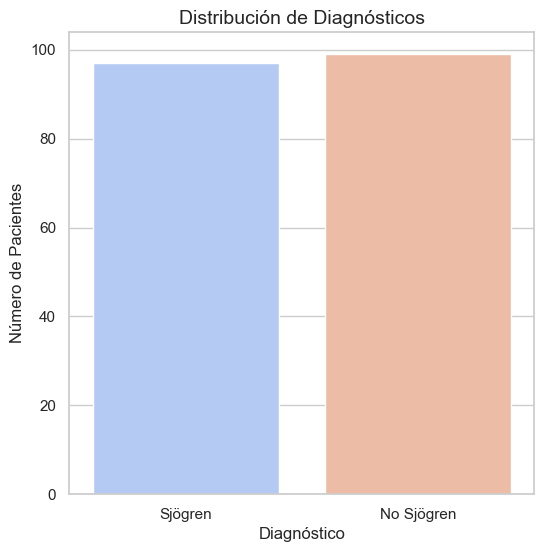

Visión general del conjunto de datos
Total de pacientes: 196
Diagnósticos de Sjögren: 97 (49.49%)
Casos que no son de Sjögren: 99 (50.51%)



In [133]:
total_pacientes = len(db_ssj)
sjogren_count = db_ssj[db_ssj['Group'] == 'sjj'].shape[0]
no_sjogren_count = db_ssj[db_ssj['Group'] == 'no-sjj'].shape[0]

porcentaje_sjogren = (sjogren_count / total_pacientes) * 100
porcentaje_no_sjogren = (no_sjogren_count / total_pacientes) * 100

plt.figure(figsize=(6, 6))
sns.barplot(x=["Sjögren", "No Sjögren"], y=[sjogren_count, no_sjogren_count], palette="coolwarm")
plt.title("Distribución de Diagnósticos", fontsize=14)
plt.ylabel("Número de Pacientes")
plt.xlabel("Diagnóstico")
plt.show()

print("Visión general del conjunto de datos")
print(f"Total de pacientes: {total_pacientes}")
print(f"Diagnósticos de Sjögren: {sjogren_count} ({porcentaje_sjogren:.2f}%)")
print(f"Casos que no son de Sjögren: {no_sjogren_count} ({porcentaje_no_sjogren:.2f}%)\n")

En el conjunto de datos, los valores para la columna de diagnóstico de Sjögren (Group) son los siguientes:

* Clase 'no-sjj' (sin diagnóstico de Sjögren): 99  casos (~50.51%)
* Clase 'sjj' (diagnóstico positivo de Sjögren): 97  casos (~49.49%)

### Variables discretas

In [134]:
levels = pd.DataFrame(columns = ['Número', 'Levels'])
for atributo in DISCRETOS:
    valores = list(db_ssj[atributo].value_counts().keys())
    levels.loc[atributo] = (len(valores), valores)
levels

,Número,Levels
Menstrual_status,2,"[Post, Pre]"
Genre,1,[Female]
Sport,5,"[0.0, 4.0, 1.0, 3.0, 2.0]"
Special_Diet,6,"[2.0, 0.0, 1.0, 8.0, 6.0, 3.0]"
Sugar_Intake,2,"[0.0, 1.0]"
Sugar_between meals,2,"[0.0, 1.0]"
Smoking,2,"[0.0, 1.0]"
Caffeine,2,"[1.0, 0.0]"
Alcohol_drinks,2,"[0.0, 1.0]"
Cardiovascular,2,"[0.0, 1.0]"


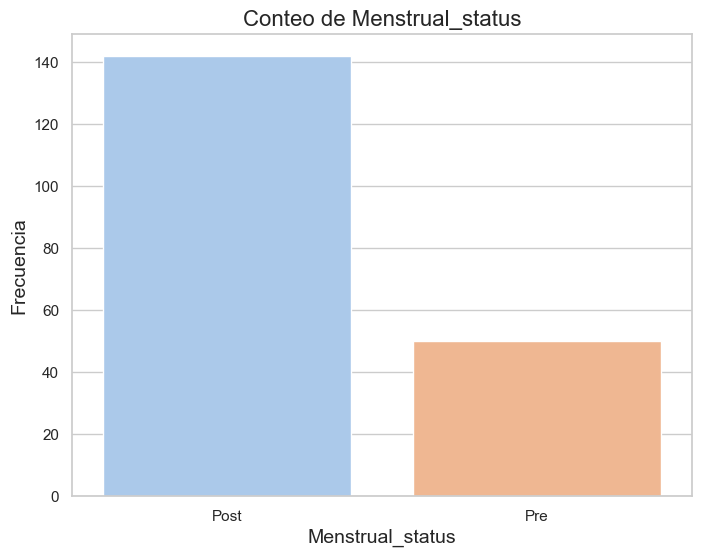

Frecuencia de valores en Menstrual_status:
Menstrual_status
Post    142
Pre      50
Name: count, dtype: int64
----------------------------------------


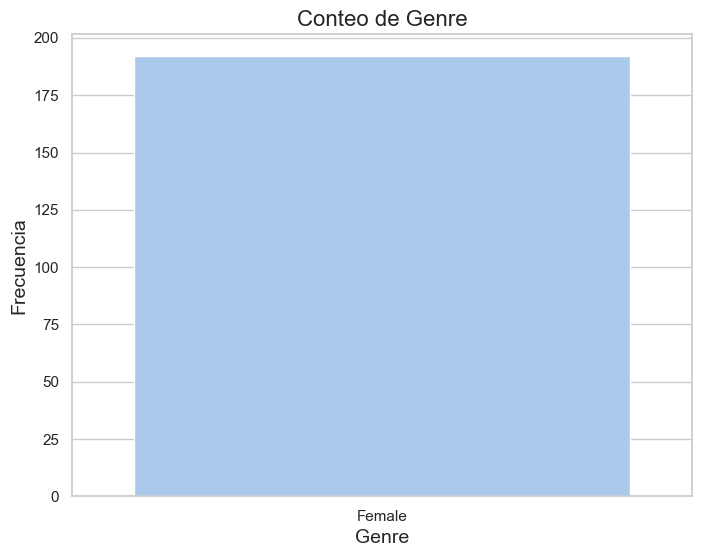

Frecuencia de valores en Genre:
Genre
Female    192
Name: count, dtype: int64
----------------------------------------


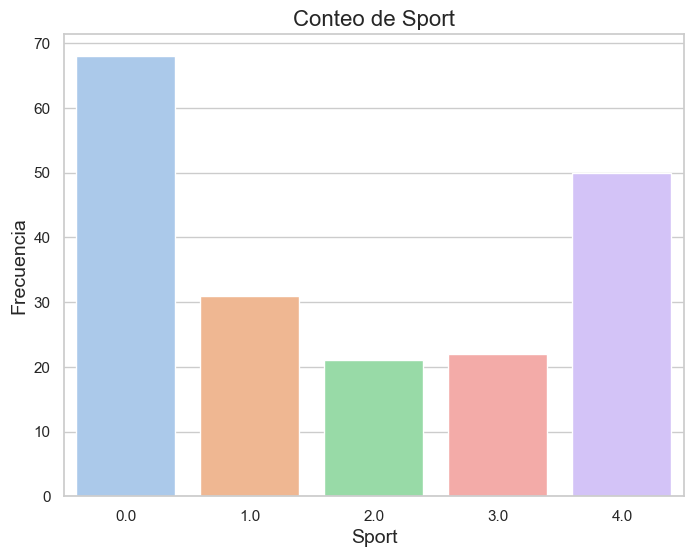

Frecuencia de valores en Sport:
Sport
0.0    68
4.0    50
1.0    31
3.0    22
2.0    21
Name: count, dtype: int64
----------------------------------------


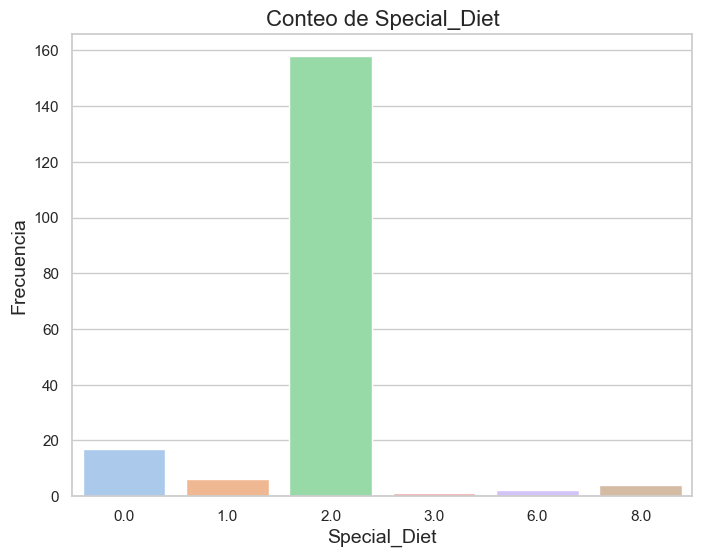

Frecuencia de valores en Special_Diet:
Special_Diet
2.0    158
0.0     17
1.0      6
8.0      4
6.0      2
3.0      1
Name: count, dtype: int64
----------------------------------------


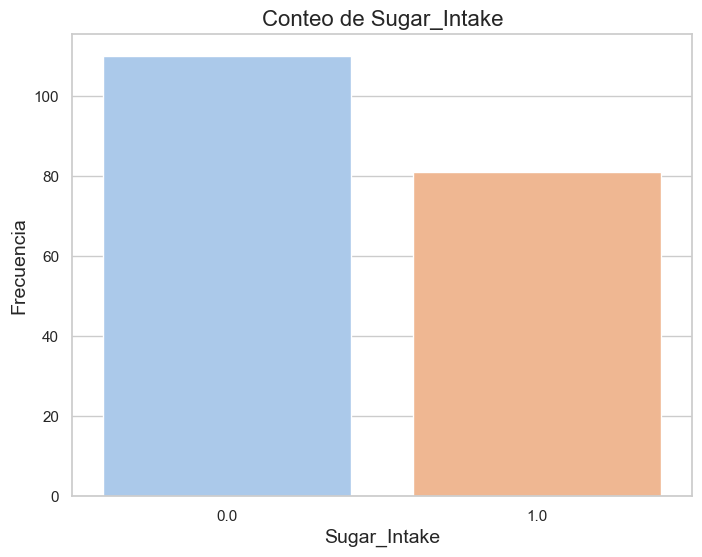

Frecuencia de valores en Sugar_Intake:
Sugar_Intake
0.0    110
1.0     81
Name: count, dtype: int64
----------------------------------------


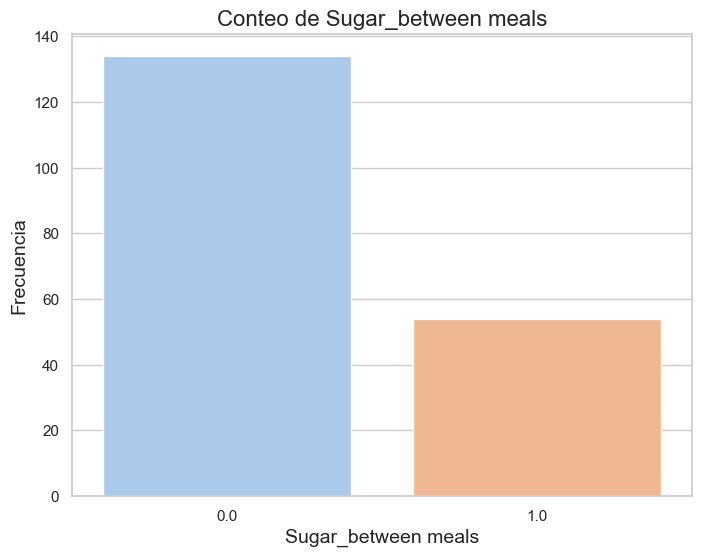

Frecuencia de valores en Sugar_between meals:
Sugar_between meals
0.0    134
1.0     54
Name: count, dtype: int64
----------------------------------------


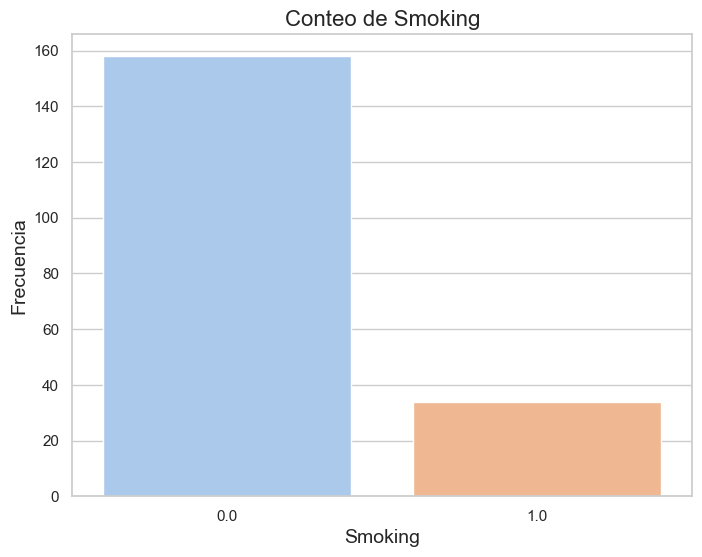

Frecuencia de valores en Smoking:
Smoking
0.0    158
1.0     34
Name: count, dtype: int64
----------------------------------------


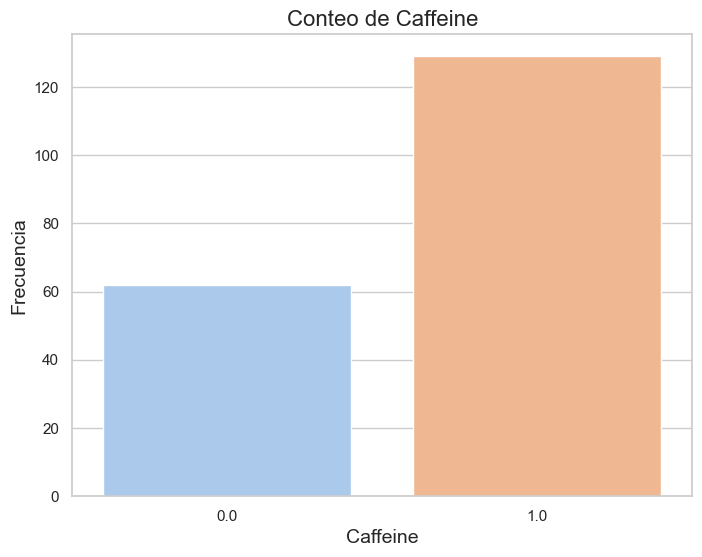

Frecuencia de valores en Caffeine:
Caffeine
1.0    129
0.0     62
Name: count, dtype: int64
----------------------------------------


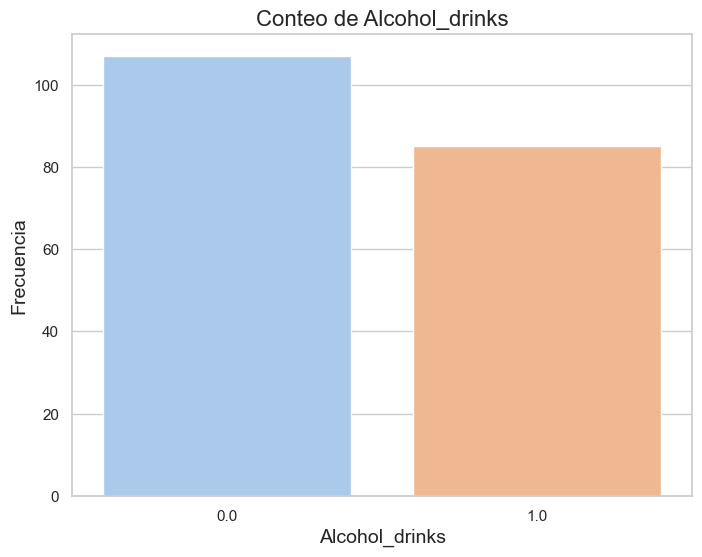

Frecuencia de valores en Alcohol_drinks:
Alcohol_drinks
0.0    107
1.0     85
Name: count, dtype: int64
----------------------------------------


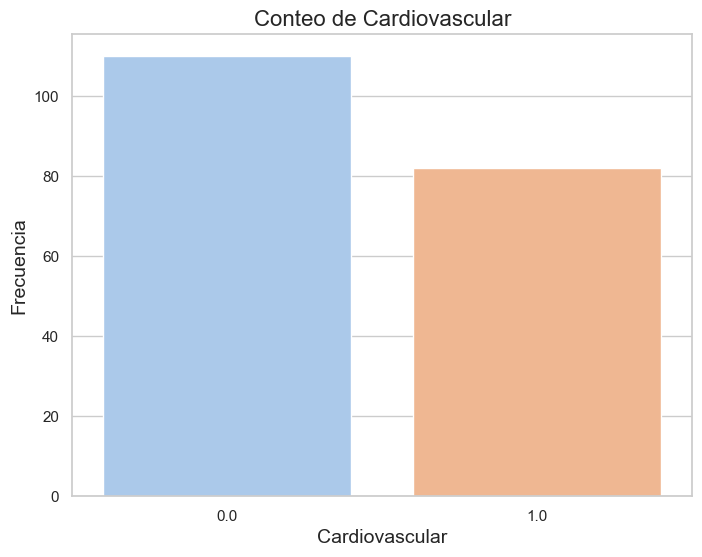

Frecuencia de valores en Cardiovascular:
Cardiovascular
0.0    110
1.0     82
Name: count, dtype: int64
----------------------------------------


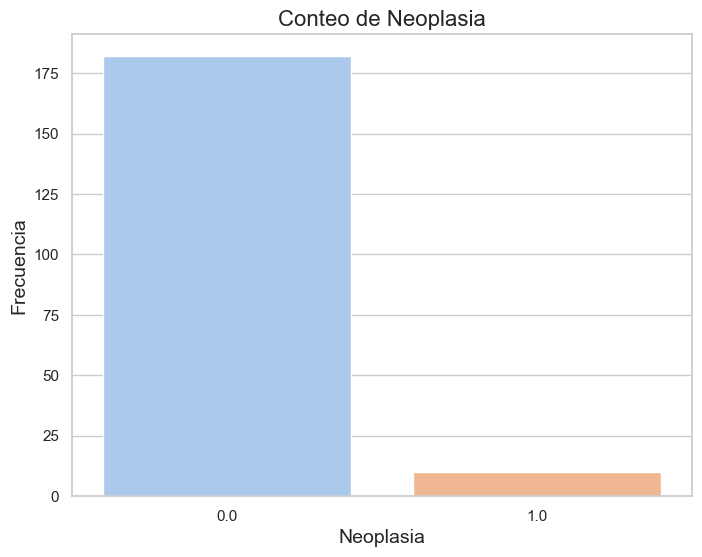

Frecuencia de valores en Neoplasia:
Neoplasia
0.0    182
1.0     10
Name: count, dtype: int64
----------------------------------------


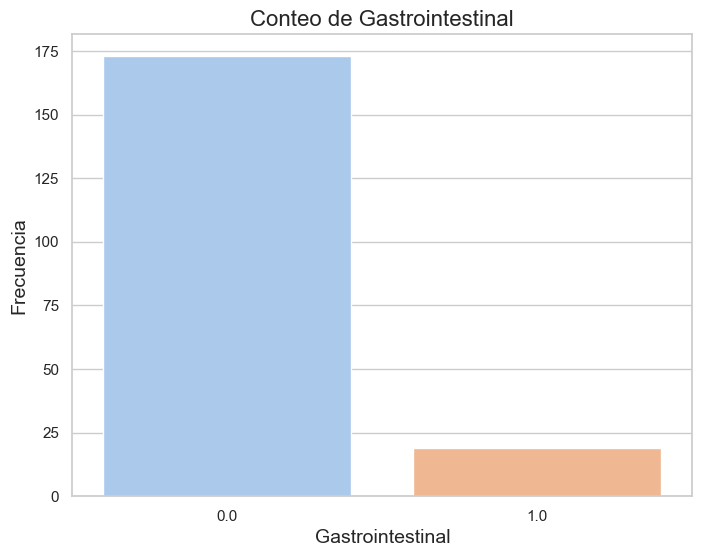

Frecuencia de valores en Gastrointestinal:
Gastrointestinal
0.0    173
1.0     19
Name: count, dtype: int64
----------------------------------------


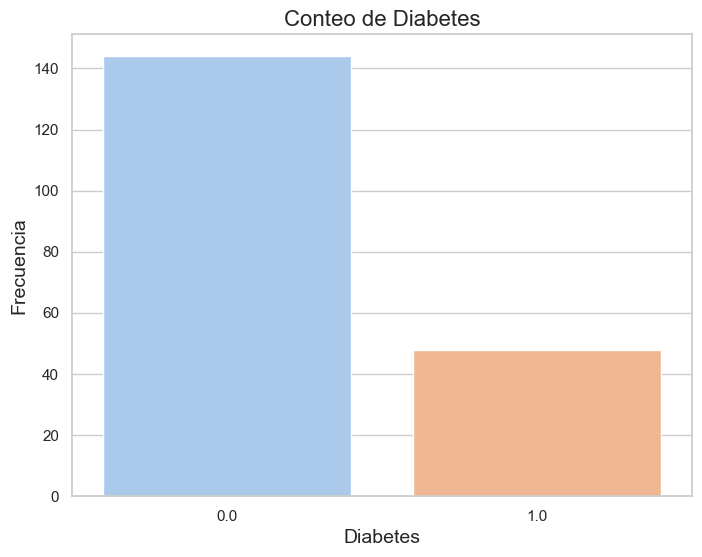

Frecuencia de valores en Diabetes:
Diabetes
0.0    144
1.0     48
Name: count, dtype: int64
----------------------------------------


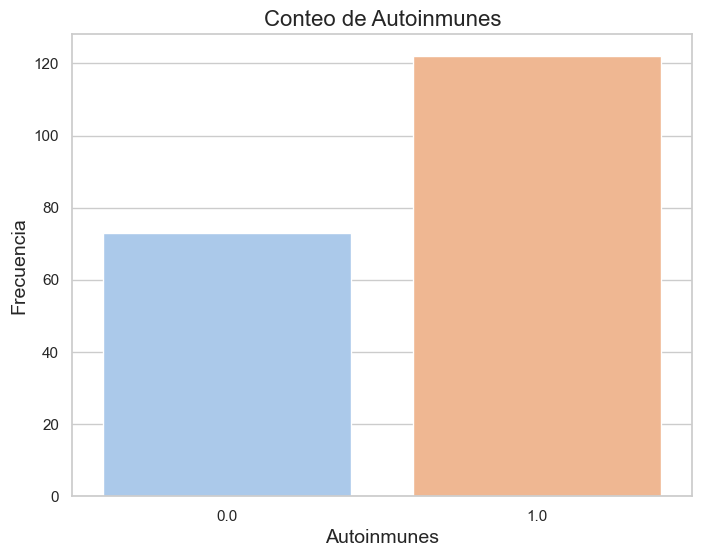

Frecuencia de valores en Autoinmunes:
Autoinmunes
1.0    122
0.0     73
Name: count, dtype: int64
----------------------------------------


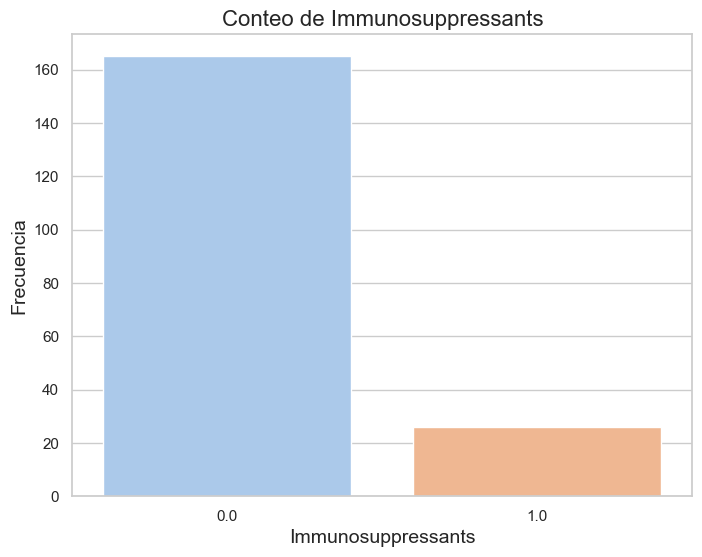

Frecuencia de valores en Immunosuppressants:
Immunosuppressants
0.0    165
1.0     26
Name: count, dtype: int64
----------------------------------------


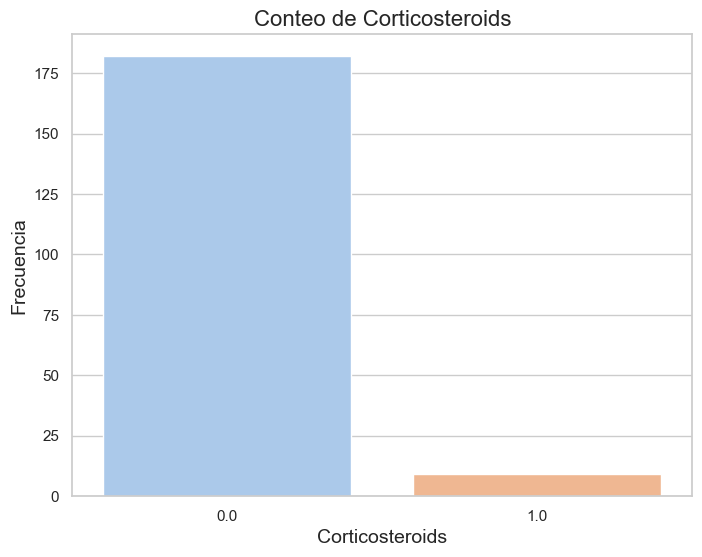

Frecuencia de valores en Corticosteroids:
Corticosteroids
0.0    182
1.0      9
Name: count, dtype: int64
----------------------------------------


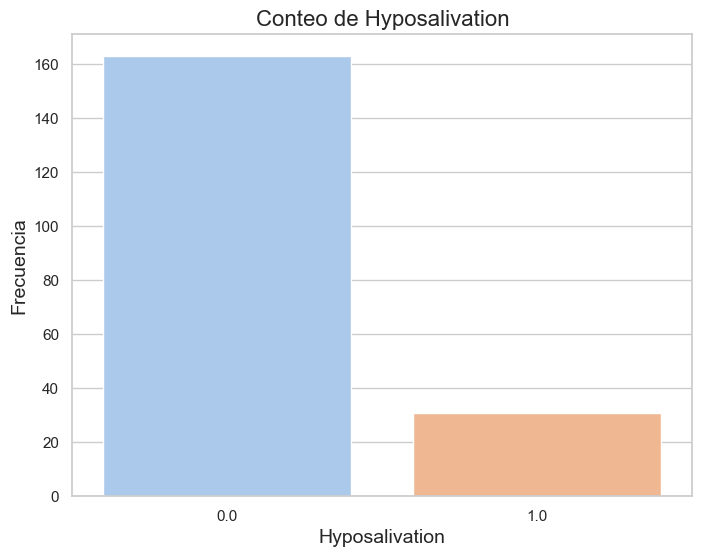

Frecuencia de valores en Hyposalivation:
Hyposalivation
0.0    163
1.0     31
Name: count, dtype: int64
----------------------------------------


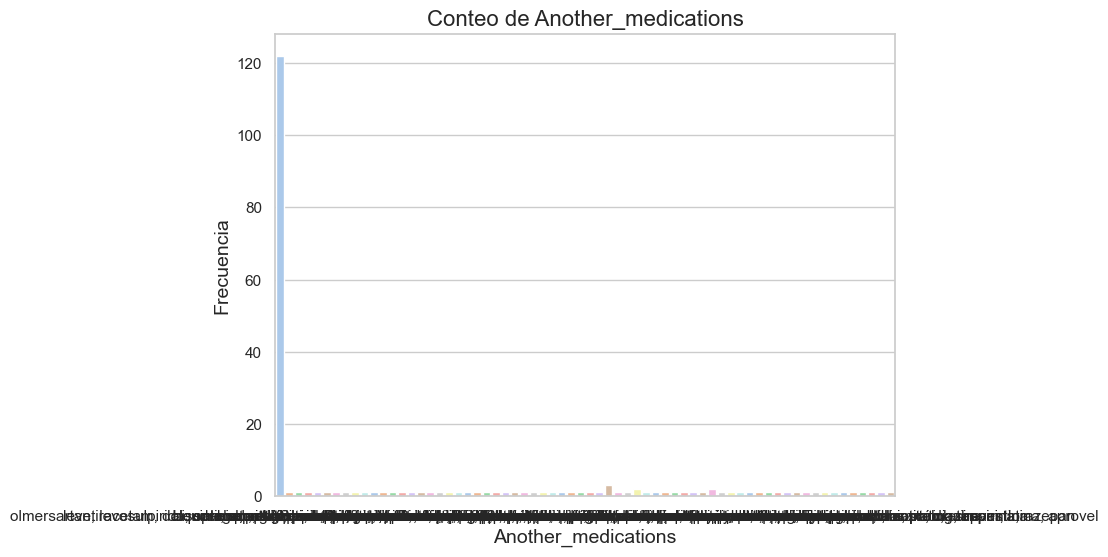

Frecuencia de valores en Another_medications:
Another_medications
0                                                                 122
enalapril                                                           3
ácido alendrónico                                                   2
olmetec, bisoprolol, eutilonio, esomeprazol,cymbalta                2
candesartán, lormetazepam                                           1
                                                                 ... 
alodipina, metformina, hierro                                       1
metamizol, losartán, hidroclorotiazida                              1
enalapril, omeprazol, motigina, lorazepam                           1
lorazepam                                                           1
eutirox, pradaxa, omeprazol, bisoprolol, simvastatina, aprovel      1
Name: count, Length: 66, dtype: int64
----------------------------------------


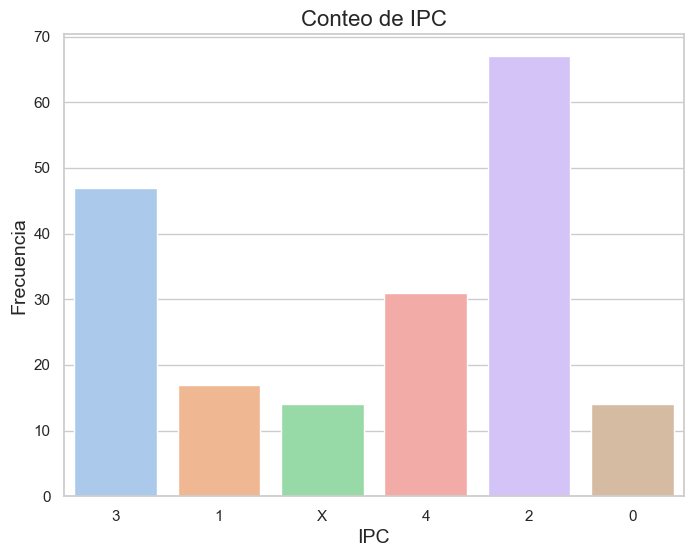

Frecuencia de valores en IPC:
IPC
2    67
3    47
4    31
1    17
X    14
0    14
Name: count, dtype: int64
----------------------------------------


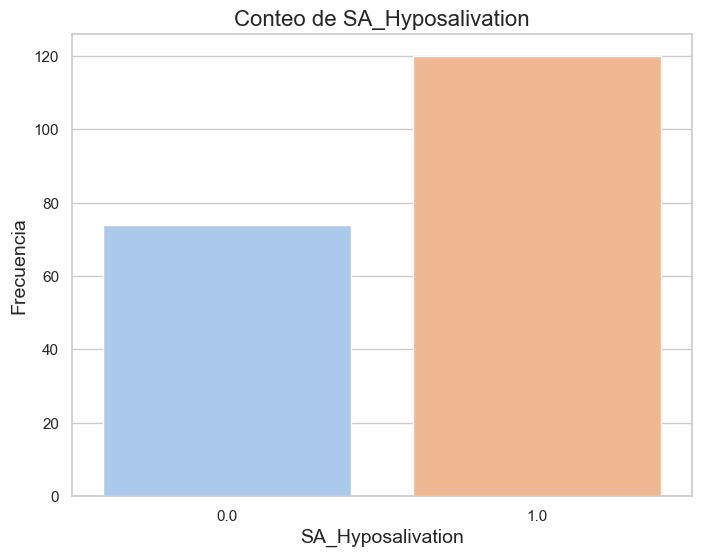

Frecuencia de valores en SA_Hyposalivation:
SA_Hyposalivation
1.0    120
0.0     74
Name: count, dtype: int64
----------------------------------------


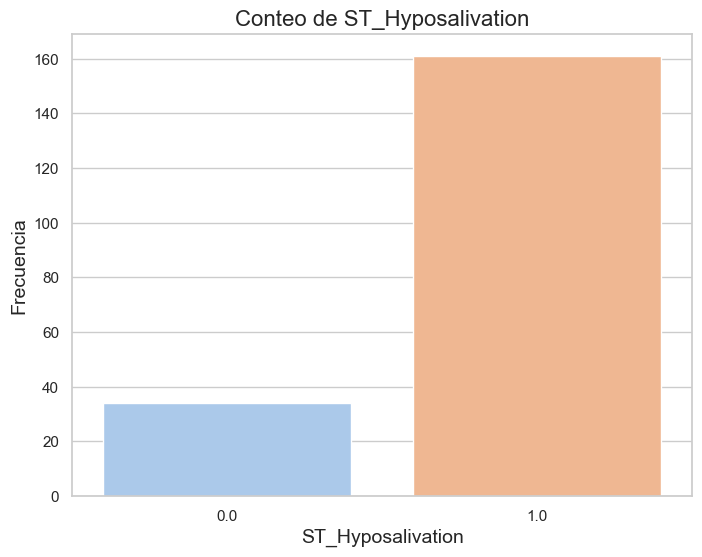

Frecuencia de valores en ST_Hyposalivation:
ST_Hyposalivation
1.0    161
0.0     34
Name: count, dtype: int64
----------------------------------------


In [135]:
for var in DISCRETOS:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=var, data=db_ssj, palette='pastel')
    plt.title(f'Conteo de {var}', fontsize=16)
    plt.xlabel(var, fontsize=14)
    plt.ylabel('Frecuencia', fontsize=14)
    plt.show()
    print(f'Frecuencia de valores en {var}:')
    print(db_ssj[var].value_counts())
    print('-' * 40)

### Variables continuas

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


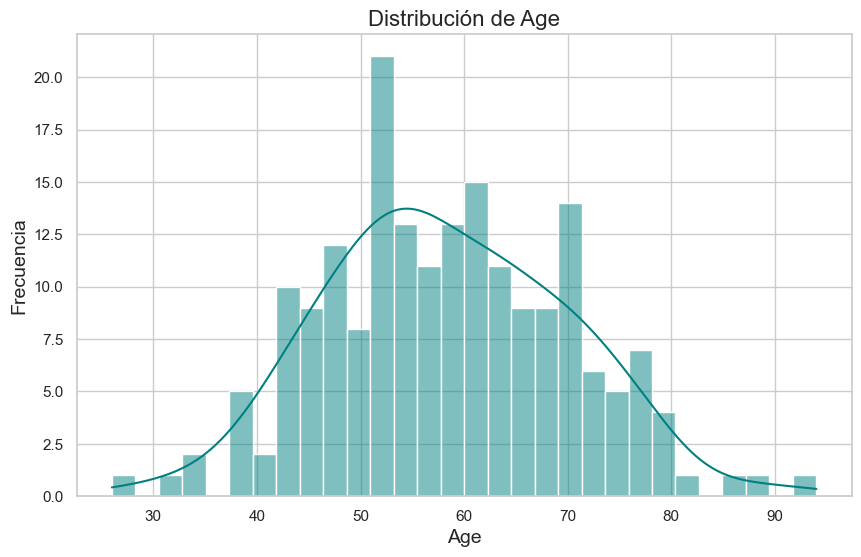

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


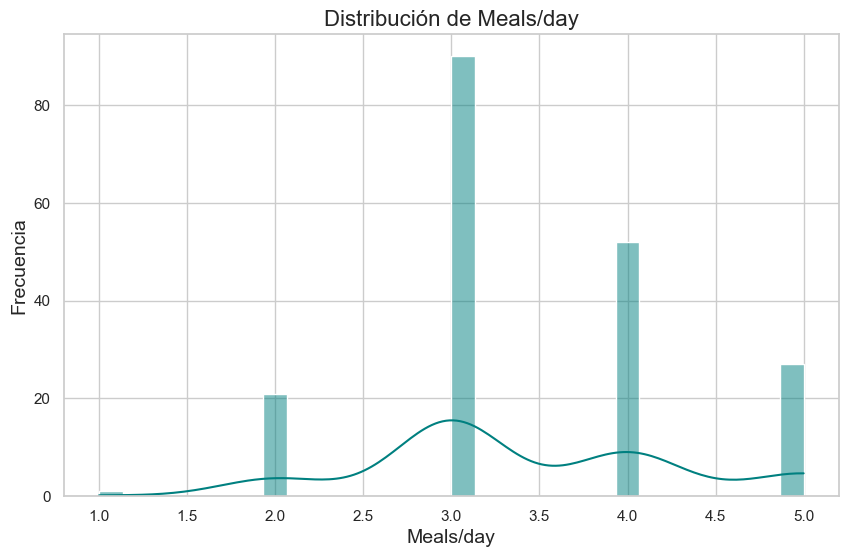

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


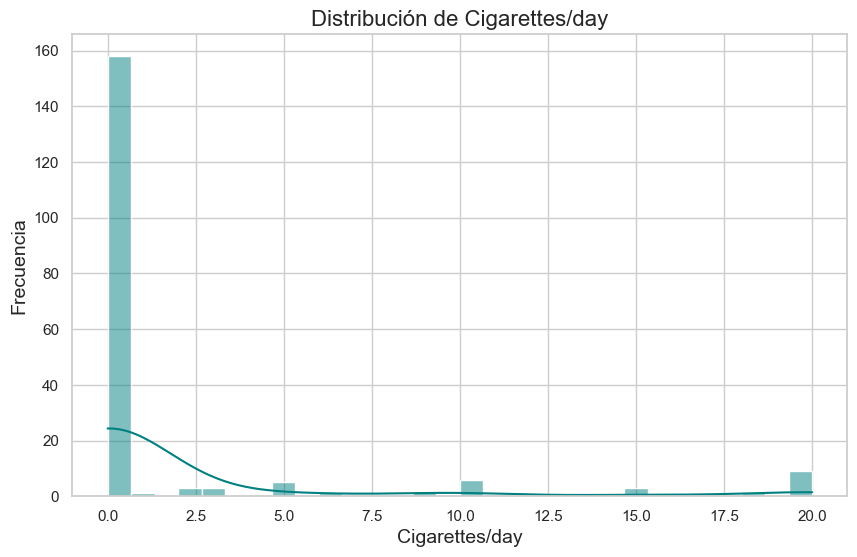

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


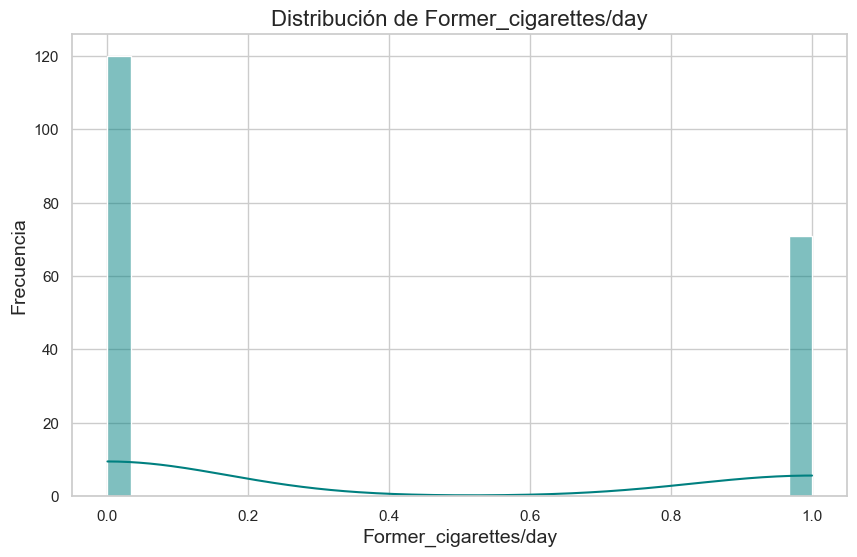

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


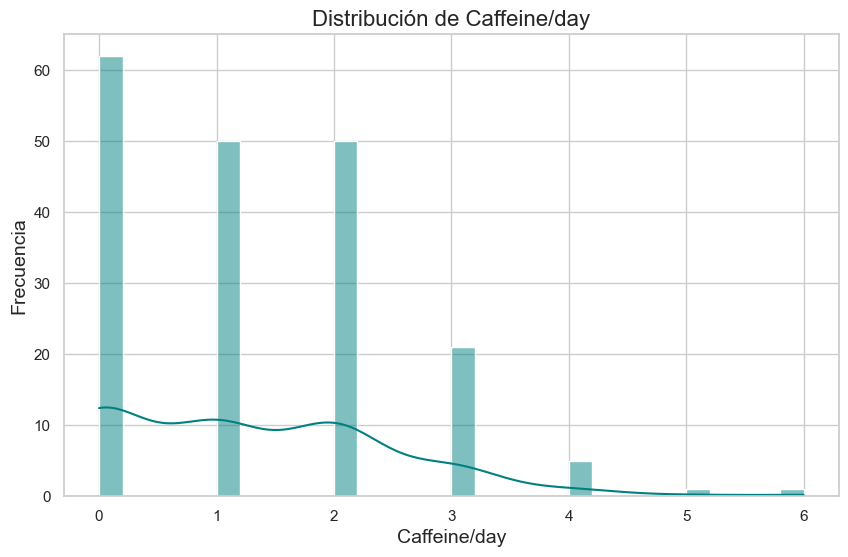

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


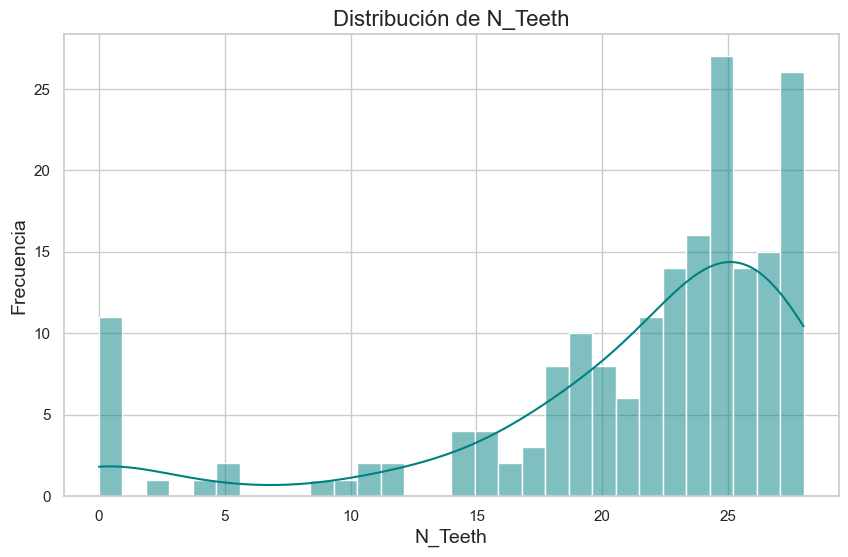

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


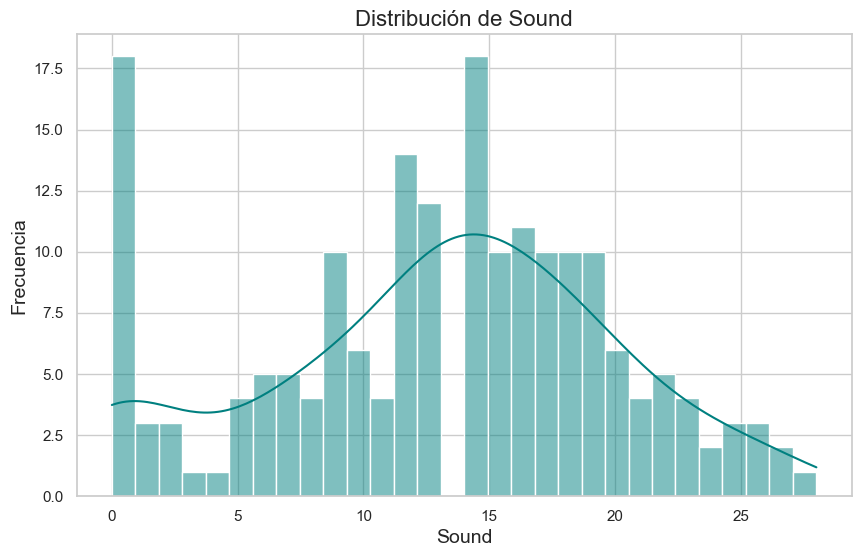

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


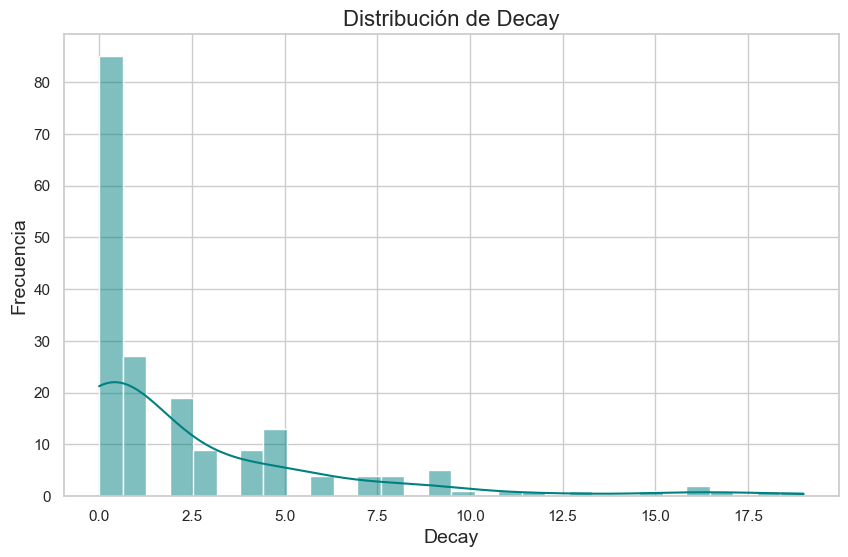

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


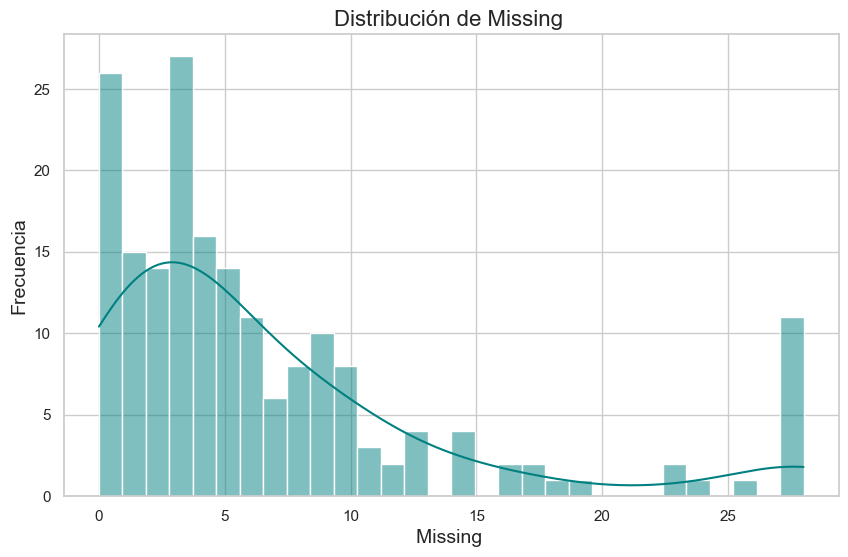

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


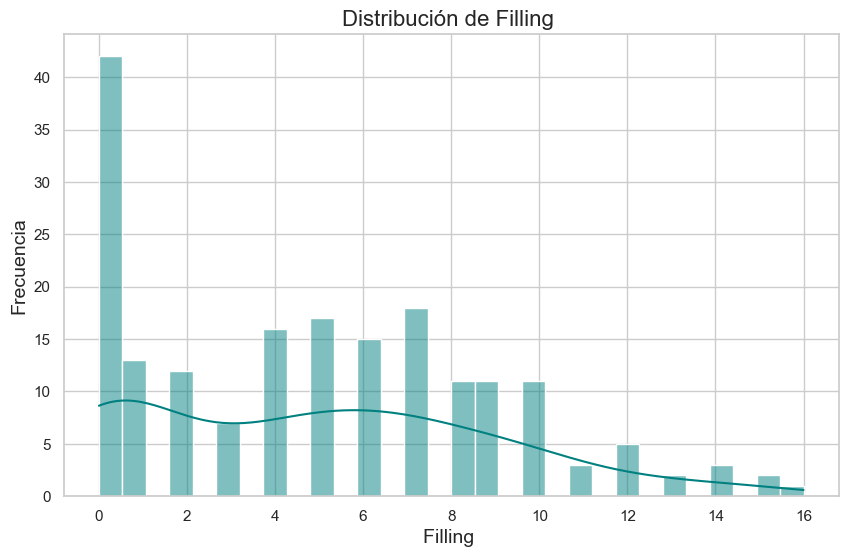

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


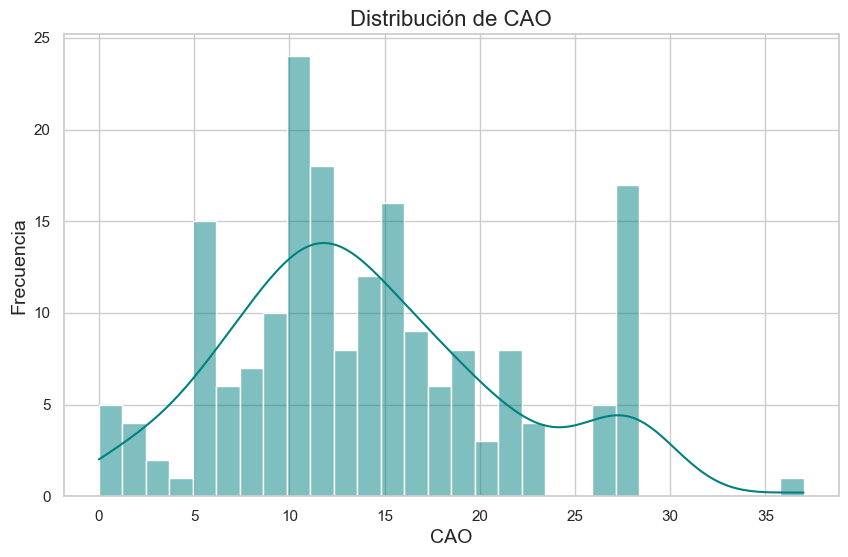

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


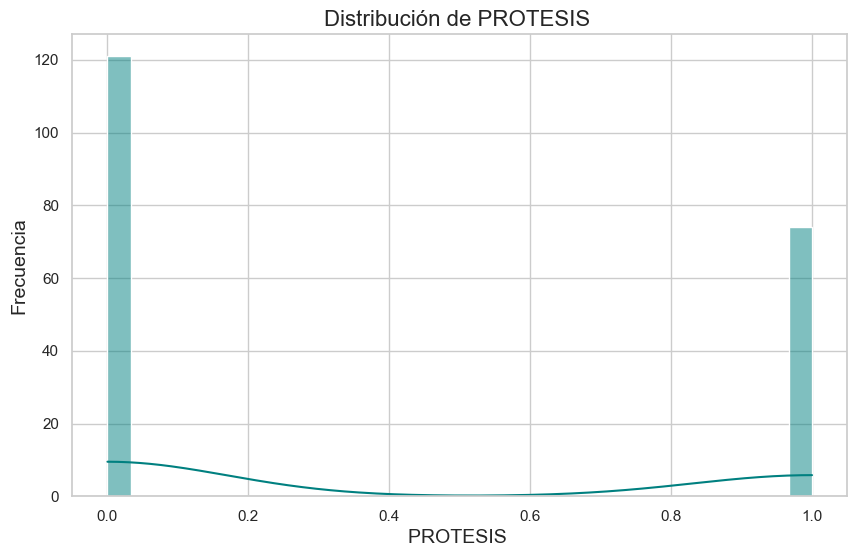

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


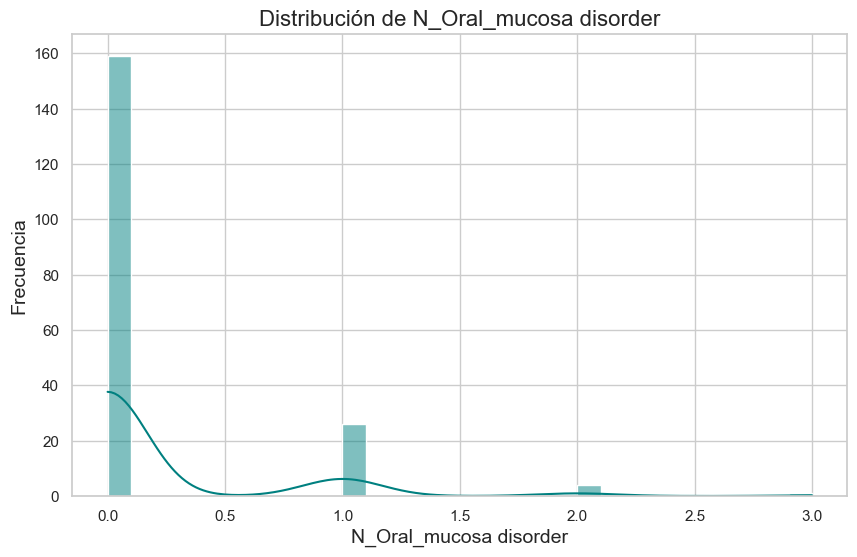

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


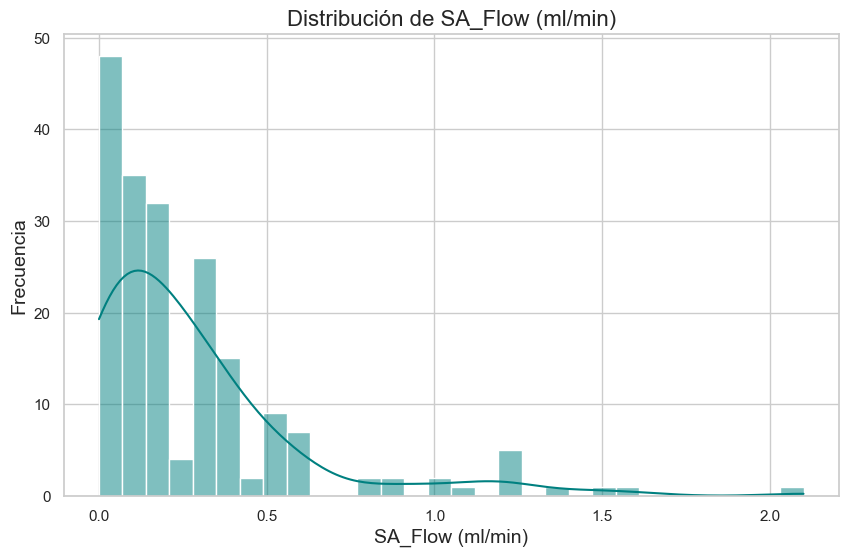

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


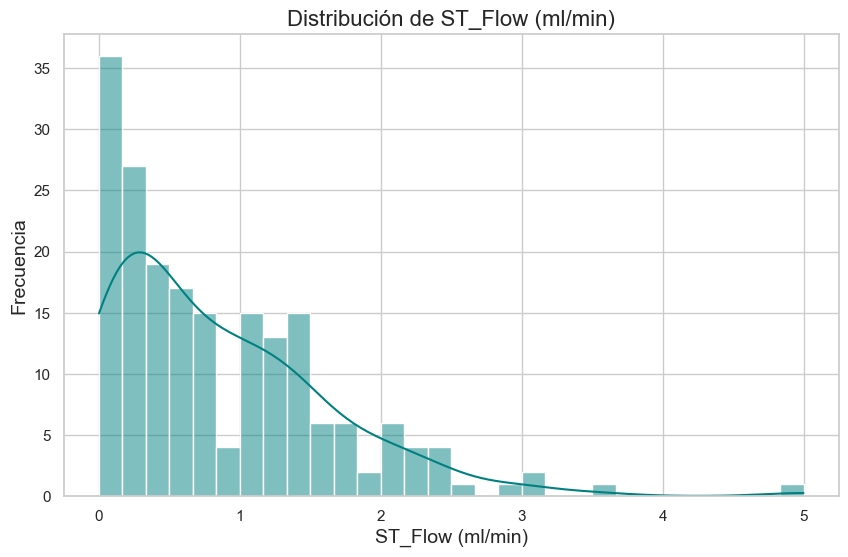

In [136]:
# Establecer el tema de Seaborn
sns.set(style="whitegrid")

# Gráfico de distribución para variables continuas
for var in CONTINUOS:
    plt.figure(figsize=(10, 6))
    sns.histplot(db_ssj[var], kde=True, color='teal', bins=30)
    plt.title(f'Distribución de {var}', fontsize=16)
    plt.xlabel(var, fontsize=14)
    plt.ylabel('Frecuencia', fontsize=14)
    plt.show()

**Distribución de Edad por Diagnóstico de Sjögren**

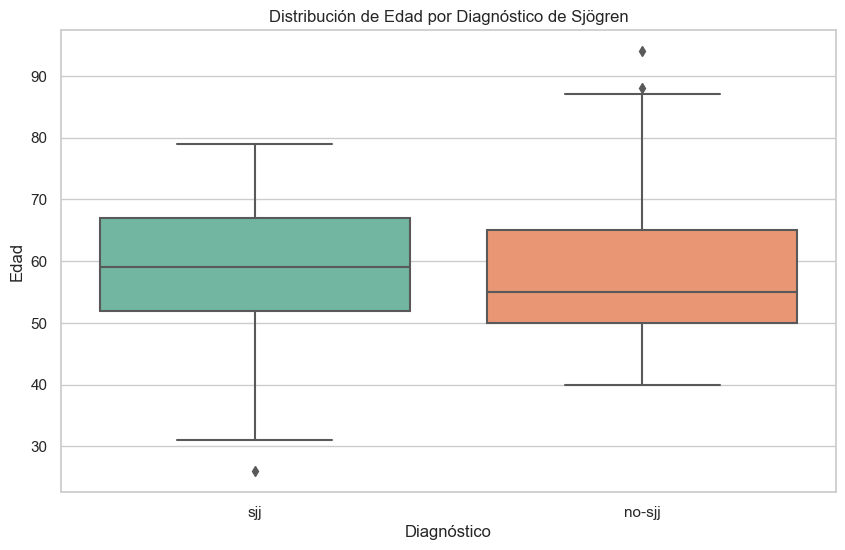

In [137]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Group', y='Age', data=db_ssj, palette='Set2')
plt.title('Distribución de Edad por Diagnóstico de Sjögren')
plt.xlabel('Diagnóstico')
plt.ylabel('Edad')
plt.show()

## 3. Preprocesamiento <a name="preprocesamiento"></a>  
### 3.1. Limpieza de datos <a name="limpieza-datos"></a>  

#### 3.1.1. Búsqueda de valores duplicados

In [138]:
mask_duplicados = db_ssj['SubjectID'].duplicated(keep=False)
valores_duplicados = db_ssj.loc[mask_duplicados, 'SubjectID']
valores_concretos_duplicados = valores_duplicados.unique()
print("Pacientes duplicados:", valores_concretos_duplicados)

Pacientes duplicados: []


#### 3.1.2. Búsqueda de valores ausentes

In [139]:
db_ssj.isna().sum()/len(db_ssj)*100

SubjectID                 0.000000
Group                     0.000000
Age                       2.040816
Menstrual_status          2.040816
Genre                     2.040816
Sport                     2.040816
Meals/day                 2.551020
Special_Diet              4.081633
Sugar_Intake              2.551020
Sugar_between meals       4.081633
Smoking                   2.040816
Cigarettes/day            2.040816
Former_cigarettes/day     2.551020
Caffeine                  2.551020
Caffeine/day              3.061224
Alcohol_drinks            2.040816
Cardiovascular            2.040816
Neoplasia                 2.040816
Gastrointestinal          2.040816
Diabetes                  2.040816
Autoinmunes               0.510204
Immunosuppressants        2.551020
Corticosteroids           2.551020
Hyposalivation            1.020408
Another_medications       2.551020
N_Teeth                   3.571429
Sound                     3.571429
Decay                     3.571429
Missing             

<Axes: >

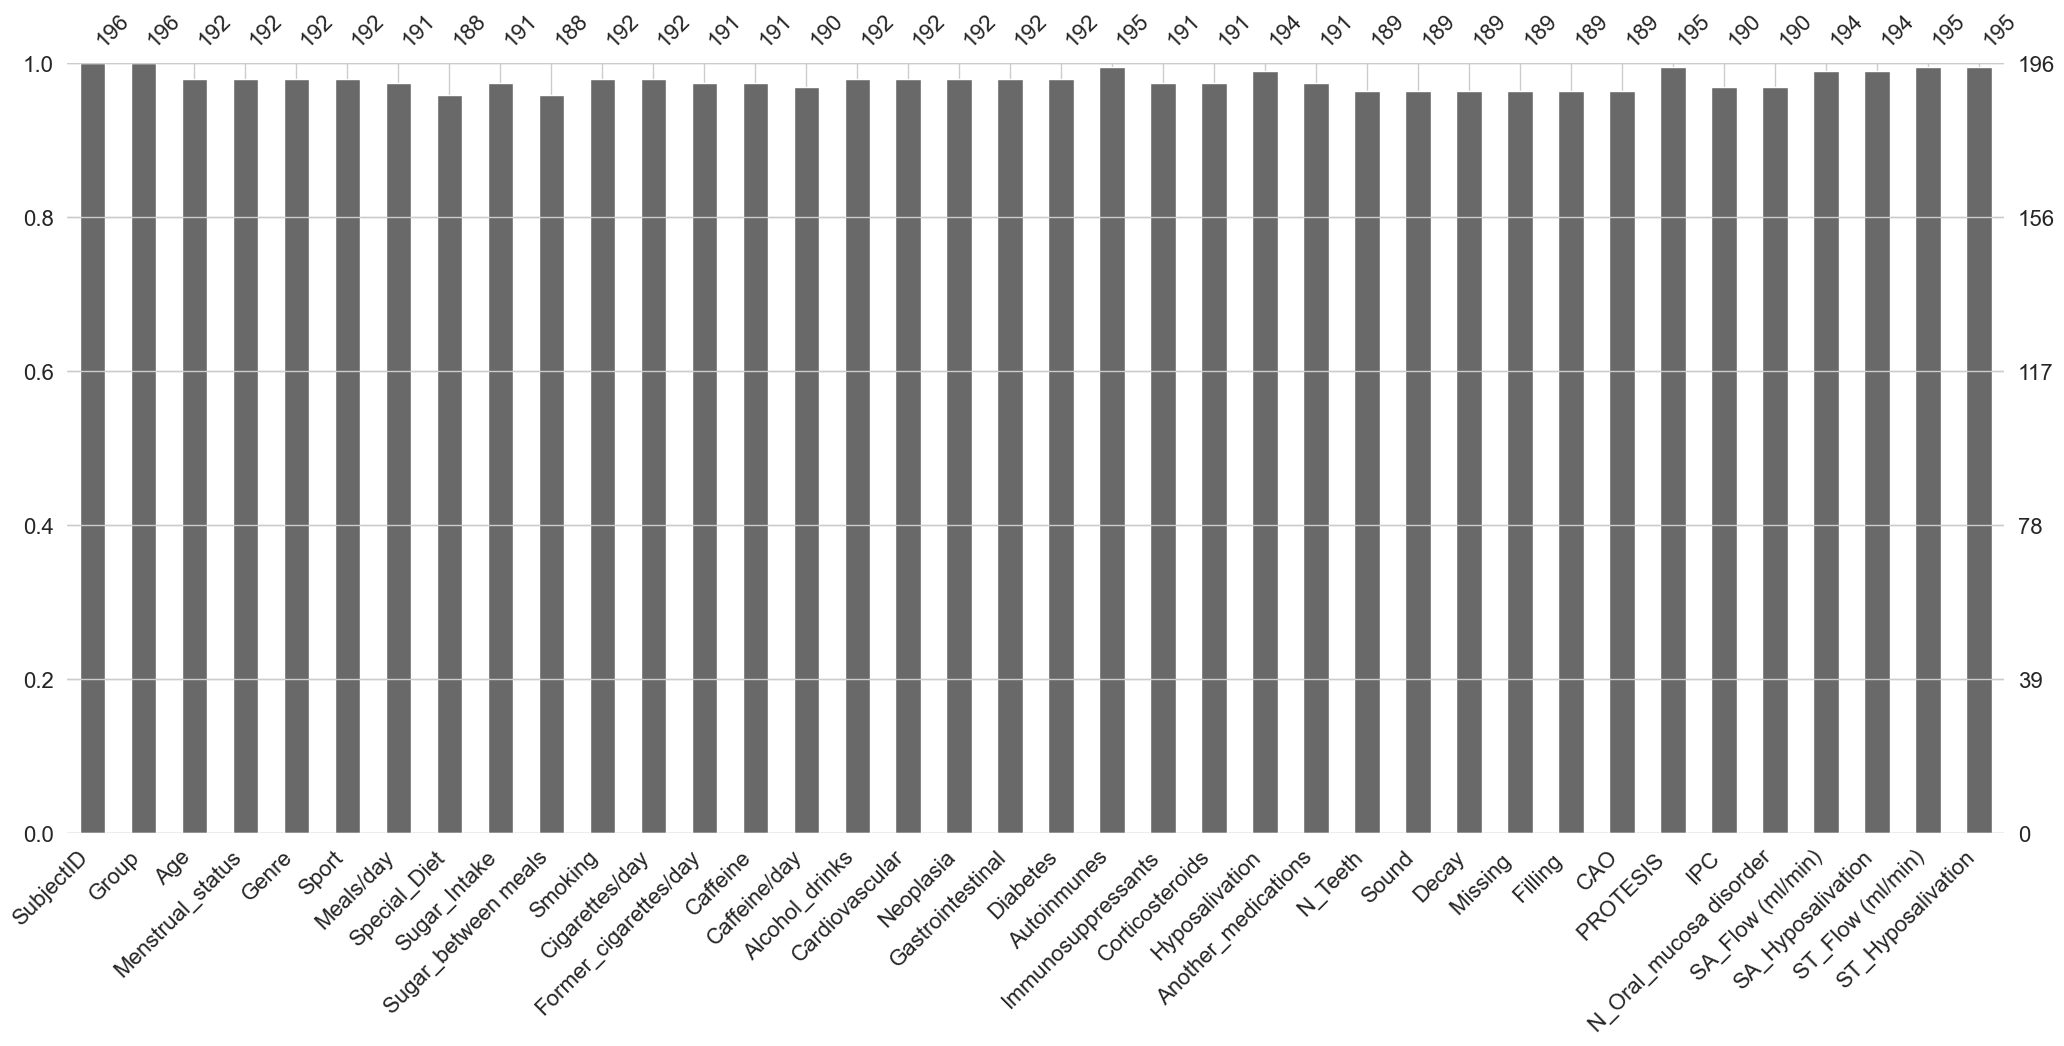

In [140]:
msno.bar(db_ssj)

In [141]:
pacientes_nulos = db_ssj[db_ssj.isnull().any(axis=1)]
subject_nulos = pacientes_nulos["SubjectID"].tolist()
total_nulos = len(pacientes_nulos)

print("Pacientes con valores nulos:", subject_nulos)
print(f"Total de pacientes con valores nulos: {total_nulos}")
print(f"Lo pacientes nulos representan el {total_nulos/len(db_ssj)*100} del dataset")

Pacientes con valores nulos: ['SSVM005', 'SSVM014', 'SSVM015', 'SSVM031', 'SSVM034', 'SSVM069', 'SSVM070', 'SSVM071', 'SSVM072', 'SSVM077', 'SSVM083', 'SSVM094', 'SSVM098', 'SSVM099', 'SSVM100', 'US001', 'US004', 'US009', 'US011', 'US012', 'US014', 'US022', 'US048', 'US065', 'US069', 'US074', 'US085', 'US093']
Total de pacientes con valores nulos: 28
Lo pacientes nulos representan el 14.285714285714285 del dataset


A pesar de que el porcentaje de valores perdidos por variable es, en general, bajo (inferior al 5% en la mayoría de los casos), al analizar el conjunto completo de datos observamos que un número considerable de pacientes presenta al menos un valor nulo. Concretamente, un 14,3% de los individuos del estudio tiene datos incompletos, lo cual supone una proporción significativa de la muestra total.

Dado que eliminar estos registros implicaría una pérdida importante de información y podría introducir sesgos en los análisis posteriores, se ha decidido no excluir los pacientes con valores perdidos. En su lugar, se optará por una estrategia de imputación diferenciada según el tipo de variable afectada. Así, se imputarán los valores faltantes utilizando técnicas simples pero adecuadas para cada caso: la moda para variables categóricas, la mediana para variables cotinuas, y métodos específicos cuando la naturaleza de la variable lo requiera. Esta aproximación permite conservar el mayor volumen posible de información sin comprometer la calidad del análisis.

#### 3.1.3. Eliminar colummnas innecesarias

subject ID no aporta información
Genre todos los usjetos son femeninos por lo que no hay variablidadad en los datos y aquellos datos continuos no nos ofrecen información.

In [142]:
data_limpio = db_ssj.drop(columns=['Genre'])
data_limpio.head()

,SubjectID,Group,Age,Menstrual_status,Sport,Meals/day,Special_Diet,Sugar_Intake,Sugar_between meals,Smoking,...,Missing,Filling,CAO,PROTESIS,IPC,N_Oral_mucosa disorder,SA_Flow (ml/min),SA_Hyposalivation,ST_Flow (ml/min),ST_Hyposalivation
0,SSVM001,sjj,60.0,Post,2.0,2.0,2.0,0.0,0.0,1.0,...,5.0,10.0,16.0,0.0,3,0.0,0.008,1.0,0.9,1.0
1,SSVM002,sjj,42.0,Pre,1.0,3.0,2.0,0.0,0.0,0.0,...,0.0,7.0,7.0,0.0,1,0.0,0.100,1.0,1.2,1.0
2,SSVM003,sjj,46.0,Pre,3.0,4.0,2.0,1.0,1.0,0.0,...,2.0,16.0,18.0,0.0,3,0.0,0.130,1.0,0.8,1.0
3,SSVM004,sjj,70.0,Post,3.0,4.0,2.0,1.0,1.0,0.0,...,28.0,0.0,28.0,1.0,X,0.0,0.200,1.0,0.6,1.0
4,SSVM005,sjj,48.0,NaN,2.0,5.0,2.0,1.0,1.0,1.0,...,9.0,2.0,19.0,0.0,4,0.0,0.018,1.0,0.6,1.0


### 3.2. Transformación de datos <a name="transformacion-datos"></a>  

**Medications**

Como la variable Another Medications suponía un campo de texto libre cuyo tratamiento con OHE podía suponer en un aumento considerable de la dimensionalidad del dataset, se optó por una agrupación alternativa de estos medicamentos en vez de tratarlos individualmente.

Para ello, agrupamos los medicamentos según si podrucían hiposalivsción o no, en función del siguiente esquema. Resulñtanfo en la variable 'Hyposalivation'. A la cual renombraremos como 'Hyposalivation_med' y procederemos a eliminar la variable 'Another_medications'.

In [143]:
data_limpio = data_limpio.drop(columns=['Another_medications'])
data_limpio = data_limpio.rename(columns={'Hyposalivation': 'Hyposalivation_med'})
data_limpio.head()

,SubjectID,Group,Age,Menstrual_status,Sport,Meals/day,Special_Diet,Sugar_Intake,Sugar_between meals,Smoking,...,Missing,Filling,CAO,PROTESIS,IPC,N_Oral_mucosa disorder,SA_Flow (ml/min),SA_Hyposalivation,ST_Flow (ml/min),ST_Hyposalivation
0,SSVM001,sjj,60.0,Post,2.0,2.0,2.0,0.0,0.0,1.0,...,5.0,10.0,16.0,0.0,3,0.0,0.008,1.0,0.9,1.0
1,SSVM002,sjj,42.0,Pre,1.0,3.0,2.0,0.0,0.0,0.0,...,0.0,7.0,7.0,0.0,1,0.0,0.100,1.0,1.2,1.0
2,SSVM003,sjj,46.0,Pre,3.0,4.0,2.0,1.0,1.0,0.0,...,2.0,16.0,18.0,0.0,3,0.0,0.130,1.0,0.8,1.0
3,SSVM004,sjj,70.0,Post,3.0,4.0,2.0,1.0,1.0,0.0,...,28.0,0.0,28.0,1.0,X,0.0,0.200,1.0,0.6,1.0
4,SSVM005,sjj,48.0,NaN,2.0,5.0,2.0,1.0,1.0,1.0,...,9.0,2.0,19.0,0.0,4,0.0,0.018,1.0,0.6,1.0


**Menstrual Status**

Label Encoder codifica los valores Nan por lo que crearemos un codificador nuevo que no codifique los valroes nulos.

In [144]:
def label_encode_with_nan(series):
    unique_vals = series.dropna().unique()
    mapping = {k: v for v, k in enumerate(unique_vals)}
    return series.map(mapping).astype('float')  # float para mantener NaN

In [145]:
data_limpio["Menstrual_status"] = label_encode_with_nan(data_limpio["Menstrual_status"])
data_limpio.head()

,SubjectID,Group,Age,Menstrual_status,Sport,Meals/day,Special_Diet,Sugar_Intake,Sugar_between meals,Smoking,...,Missing,Filling,CAO,PROTESIS,IPC,N_Oral_mucosa disorder,SA_Flow (ml/min),SA_Hyposalivation,ST_Flow (ml/min),ST_Hyposalivation
0,SSVM001,sjj,60.0,0.0,2.0,2.0,2.0,0.0,0.0,1.0,...,5.0,10.0,16.0,0.0,3,0.0,0.008,1.0,0.9,1.0
1,SSVM002,sjj,42.0,1.0,1.0,3.0,2.0,0.0,0.0,0.0,...,0.0,7.0,7.0,0.0,1,0.0,0.100,1.0,1.2,1.0
2,SSVM003,sjj,46.0,1.0,3.0,4.0,2.0,1.0,1.0,0.0,...,2.0,16.0,18.0,0.0,3,0.0,0.130,1.0,0.8,1.0
3,SSVM004,sjj,70.0,0.0,3.0,4.0,2.0,1.0,1.0,0.0,...,28.0,0.0,28.0,1.0,X,0.0,0.200,1.0,0.6,1.0
4,SSVM005,sjj,48.0,NaN,2.0,5.0,2.0,1.0,1.0,1.0,...,9.0,2.0,19.0,0.0,4,0.0,0.018,1.0,0.6,1.0


0 --> Post 
1 --> Pre

**IPC**

Periodontal diagnosis based on the IPC index

| Valor | Significado                                                                |
| ----- | -------------------------------------------------------------------------- |
| 0     | Healthy (No treatment required)                                            |
| 1     | Bleeding on probing (OHI + removal of subgingival plaque)                  |
| 2     | Calculus (OHI + removal of plaque and calculus)                            |
| 3     | Pocket 4–5 mm (Periodontal treatment of affected sextant)                  |
| 4     | Pocket >5.5 mm (Comprehensive periodontal treatment)                       |
| X     | Excluded sextant (no evaluación posible, no debe codificarse clínicamente) |
| 9     | Not recorded (valor faltante real, o mal registro)                         |


In [146]:
data_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SubjectID               196 non-null    object 
 1   Group                   196 non-null    object 
 2   Age                     192 non-null    float64
 3   Menstrual_status        192 non-null    float64
 4   Sport                   192 non-null    float64
 5   Meals/day               191 non-null    float64
 6   Special_Diet            188 non-null    float64
 7   Sugar_Intake            191 non-null    float64
 8   Sugar_between meals     188 non-null    float64
 9   Smoking                 192 non-null    float64
 10  Cigarettes/day          192 non-null    float64
 11  Former_cigarettes/day   191 non-null    float64
 12  Caffeine                191 non-null    float64
 13  Caffeine/day            190 non-null    float64
 14  Alcohol_drinks          192 non-null    fl

In [147]:
# Reemplazar 'X' y '9' por NaN
data_limpio["IPC"] = data_limpio["IPC"].replace({"X": np.nan, "9": np.nan})

# Convertir a numérico (esto convierte los strings válidos a números y mantiene los NaN)
data_limpio["IPC"] = pd.to_numeric(data_limpio["IPC"], errors='coerce')
data_limpio.head()

C:\Users\Kristina\AppData\Local\Temp\ipykernel_25472\1998686363.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_limpio["IPC"] = data_limpio["IPC"].replace({"X": np.nan, "9": np.nan})


,SubjectID,Group,Age,Menstrual_status,Sport,Meals/day,Special_Diet,Sugar_Intake,Sugar_between meals,Smoking,...,Missing,Filling,CAO,PROTESIS,IPC,N_Oral_mucosa disorder,SA_Flow (ml/min),SA_Hyposalivation,ST_Flow (ml/min),ST_Hyposalivation
0,SSVM001,sjj,60.0,0.0,2.0,2.0,2.0,0.0,0.0,1.0,...,5.0,10.0,16.0,0.0,3.0,0.0,0.008,1.0,0.9,1.0
1,SSVM002,sjj,42.0,1.0,1.0,3.0,2.0,0.0,0.0,0.0,...,0.0,7.0,7.0,0.0,1.0,0.0,0.100,1.0,1.2,1.0
2,SSVM003,sjj,46.0,1.0,3.0,4.0,2.0,1.0,1.0,0.0,...,2.0,16.0,18.0,0.0,3.0,0.0,0.130,1.0,0.8,1.0
3,SSVM004,sjj,70.0,0.0,3.0,4.0,2.0,1.0,1.0,0.0,...,28.0,0.0,28.0,1.0,NaN,0.0,0.200,1.0,0.6,1.0
4,SSVM005,sjj,48.0,NaN,2.0,5.0,2.0,1.0,1.0,1.0,...,9.0,2.0,19.0,0.0,4.0,0.0,0.018,1.0,0.6,1.0


**Sjögren**

In [148]:
label_encoder = LabelEncoder()
data_limpio['Group'] = label_encoder.fit_transform(data_limpio['Group'])
data_limpio = data_limpio.rename(columns={'Group': 'Sjogren'})
data_limpio.head()

,SubjectID,Sjogren,Age,Menstrual_status,Sport,Meals/day,Special_Diet,Sugar_Intake,Sugar_between meals,Smoking,...,Missing,Filling,CAO,PROTESIS,IPC,N_Oral_mucosa disorder,SA_Flow (ml/min),SA_Hyposalivation,ST_Flow (ml/min),ST_Hyposalivation
0,SSVM001,1,60.0,0.0,2.0,2.0,2.0,0.0,0.0,1.0,...,5.0,10.0,16.0,0.0,3.0,0.0,0.008,1.0,0.9,1.0
1,SSVM002,1,42.0,1.0,1.0,3.0,2.0,0.0,0.0,0.0,...,0.0,7.0,7.0,0.0,1.0,0.0,0.100,1.0,1.2,1.0
2,SSVM003,1,46.0,1.0,3.0,4.0,2.0,1.0,1.0,0.0,...,2.0,16.0,18.0,0.0,3.0,0.0,0.130,1.0,0.8,1.0
3,SSVM004,1,70.0,0.0,3.0,4.0,2.0,1.0,1.0,0.0,...,28.0,0.0,28.0,1.0,NaN,0.0,0.200,1.0,0.6,1.0
4,SSVM005,1,48.0,NaN,2.0,5.0,2.0,1.0,1.0,1.0,...,9.0,2.0,19.0,0.0,4.0,0.0,0.018,1.0,0.6,1.0


In [149]:
data_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SubjectID               196 non-null    object 
 1   Sjogren                 196 non-null    int32  
 2   Age                     192 non-null    float64
 3   Menstrual_status        192 non-null    float64
 4   Sport                   192 non-null    float64
 5   Meals/day               191 non-null    float64
 6   Special_Diet            188 non-null    float64
 7   Sugar_Intake            191 non-null    float64
 8   Sugar_between meals     188 non-null    float64
 9   Smoking                 192 non-null    float64
 10  Cigarettes/day          192 non-null    float64
 11  Former_cigarettes/day   191 non-null    float64
 12  Caffeine                191 non-null    float64
 13  Caffeine/day            190 non-null    float64
 14  Alcohol_drinks          192 non-null    fl

#### 3.1.4. Imputación de valores nulos

**Tratamiendo Imputación MICE**

In [150]:
CLASE = 'Sjogren'

CONTINUOS = ['Age', 'Meals/day', 'Cigarettes/day', 'Former_cigarettes/day', 'Caffeine/day', 'N_Teeth', 
    'Sound', 'Decay', 'Missing ', 'Filling ', 
    'CAO', 'PROTESIS ', 'N_Oral_mucosa disorder', 'SA_Flow (ml/min)', 'ST_Flow (ml/min)']

DISCRETOS = ['Menstrual_status', 'Sport', 'Special_Diet', 'Sugar_Intake', 
    'Sugar_between meals', 'Smoking', 'Caffeine', 'Alcohol_drinks', 'Cardiovascular', 'Neoplasia', 
    'Gastrointestinal', 'Diabetes', 'Autoinmunes', 'Immunosuppressants', 'Corticosteroids', 'Hyposalivation_med', 'IPC','SA_Hyposalivation', 'ST_Hyposalivation']

In [151]:
columnas_validas = data_limpio.columns

CONTINUOS = [col for col in CONTINUOS if col in columnas_validas]
DISCRETOS = [col for col in DISCRETOS if col in columnas_validas]

In [152]:
vars_numericas = CONTINUOS + DISCRETOS

# Paso 1: Imputación con IterativeImputer (MICE)
imputer = IterativeImputer(random_state=42, max_iter=10)

# Solo imputamos las columnas numéricas de data_limpio
data_imputada_array = imputer.fit_transform(data_limpio[vars_numericas])

# Convertimos a DataFrame
data_imputada = pd.DataFrame(data_imputada_array, columns=vars_numericas, index=data_limpio.index)

# Paso 2: Ajustar decimales solo para variables de flow, el resto redondear a enteros
vars_flow = ['SA_Flow (ml/min)', 'ST_Flow (ml/min)']  # Ajusta según tus variables de flow reales

for col in data_imputada.columns:
    if col in vars_flow:
        # Mantener decimales (por ejemplo 2 decimales)
        data_imputada[col] = data_imputada[col].round(2)
    else:
        # Redondear a entero y convertir a int (opcional)
        data_imputada[col] = data_imputada[col].round().astype(int)

=== Comparación variables numéricas ===

🔹 Age
   Media: 58.26 → 58.19
   Desviación estándar: 11.73 → 11.67
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


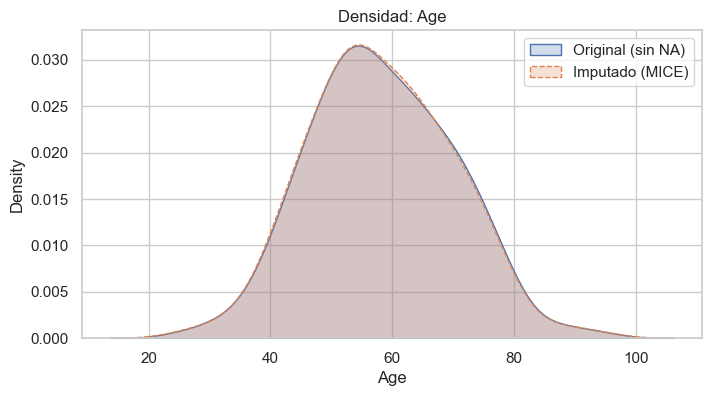


🔹 Meals/day
   Media: 3.43 → 3.42
   Desviación estándar: 0.89 → 0.88
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


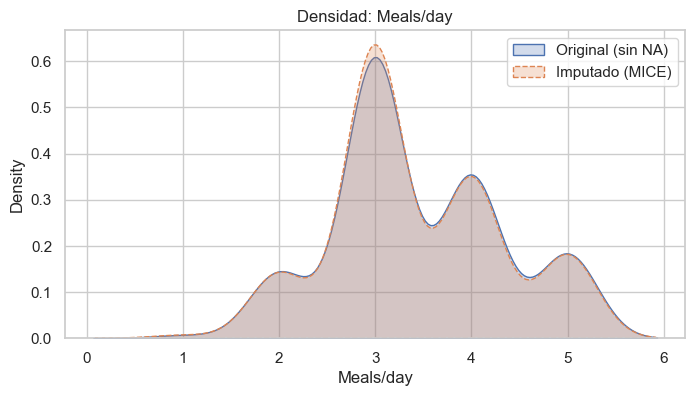


🔹 Cigarettes/day
   Media: 1.92 → 1.90
   Desviación estándar: 5.04 → 4.99
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


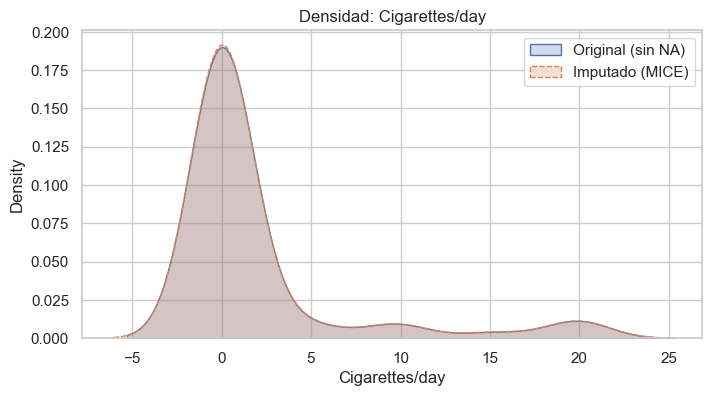


🔹 Former_cigarettes/day
   Media: 0.37 → 0.37
   Desviación estándar: 0.48 → 0.48
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


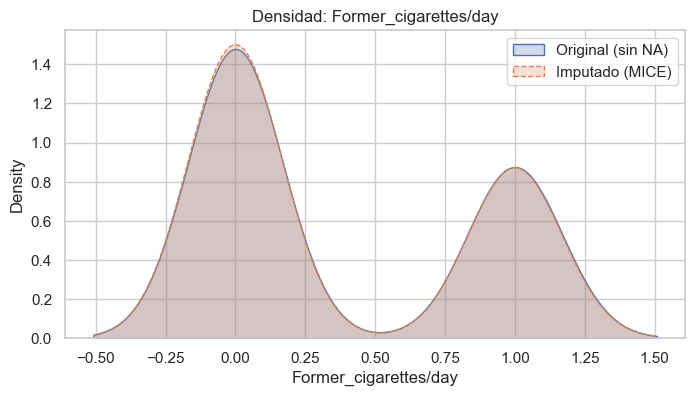

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 Caffeine/day
   Media: 1.28 → 1.29
   Desviación estándar: 1.19 → 1.18
   KS test p-value: 1.0000 (Distribuciones similares)


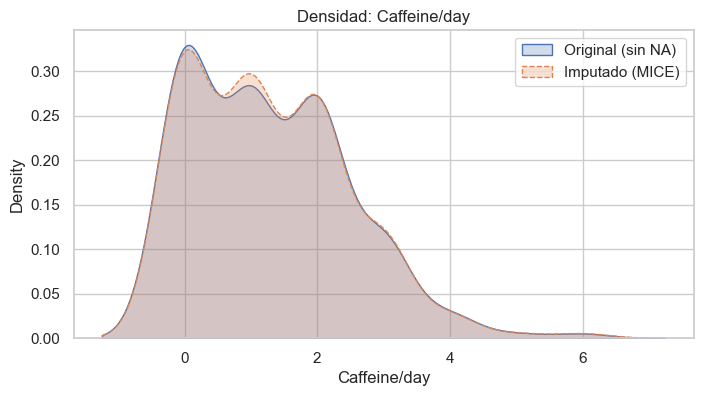


🔹 N_Teeth
   Media: 21.27 → 21.26
   Desviación estándar: 7.29 → 7.16
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


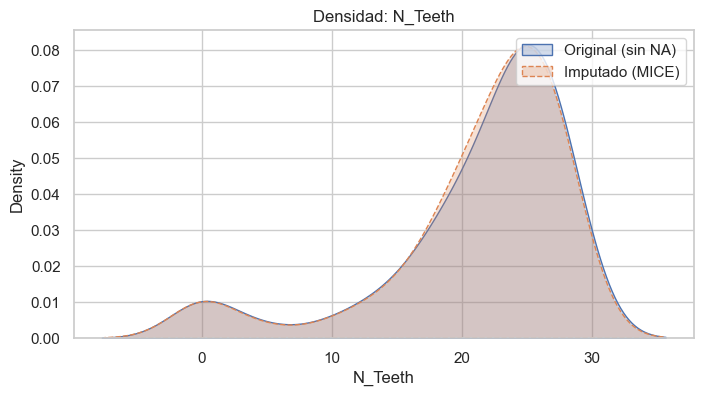

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 Sound
   Media: 13.01 → 13.04
   Desviación estándar: 6.97 → 6.85
   KS test p-value: 1.0000 (Distribuciones similares)


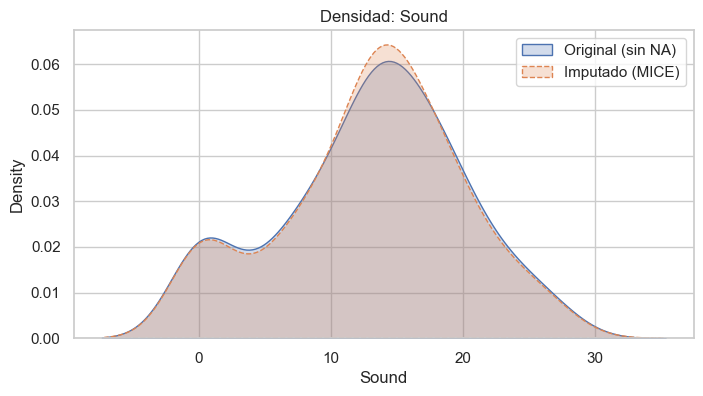


🔹 Decay
   Media: 2.48 → 2.46
   Desviación estándar: 3.81 → 3.75
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


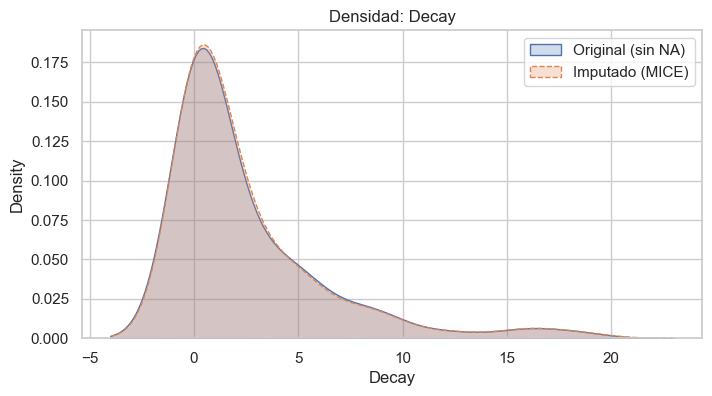


🔹 Missing 
   Media: 6.73 → 6.74
   Desviación estándar: 7.29 → 7.16
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


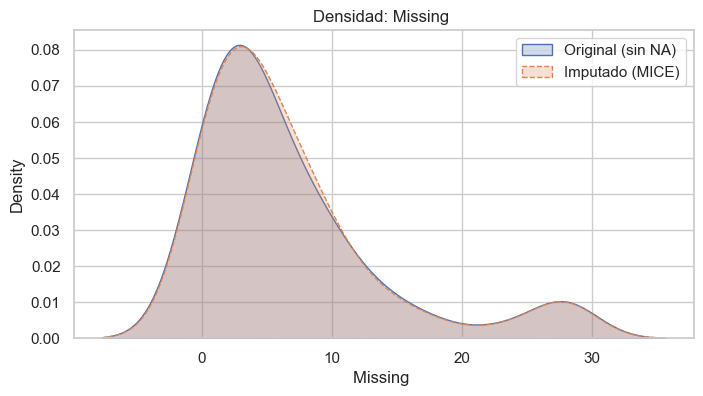


🔹 Filling 
   Media: 4.90 → 4.91
   Desviación estándar: 4.05 → 3.98
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


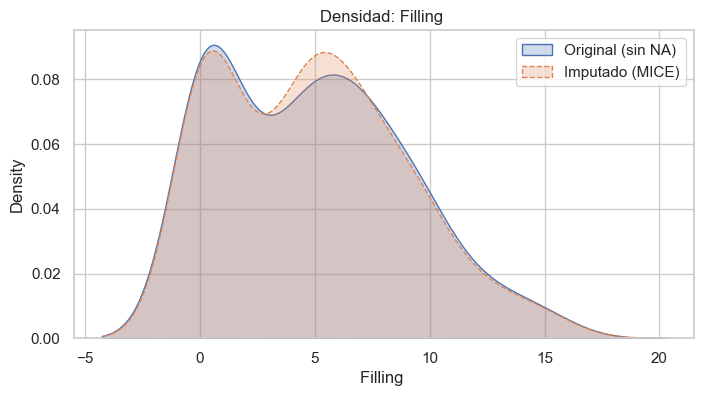

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 CAO
   Media: 14.12 → 14.11
   Desviación estándar: 7.28 → 7.14
   KS test p-value: 1.0000 (Distribuciones similares)


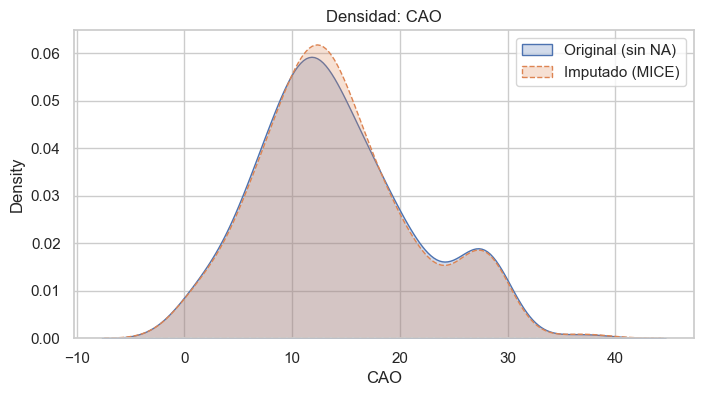

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 PROTESIS 
   Media: 0.38 → 0.38
   Desviación estándar: 0.49 → 0.49
   KS test p-value: 1.0000 (Distribuciones similares)


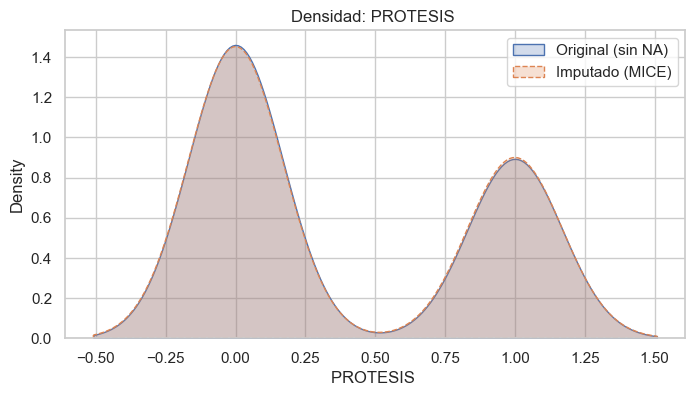

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 N_Oral_mucosa disorder
   Media: 0.19 → 0.19
   Desviación estándar: 0.48 → 0.48
   KS test p-value: 1.0000 (Distribuciones similares)


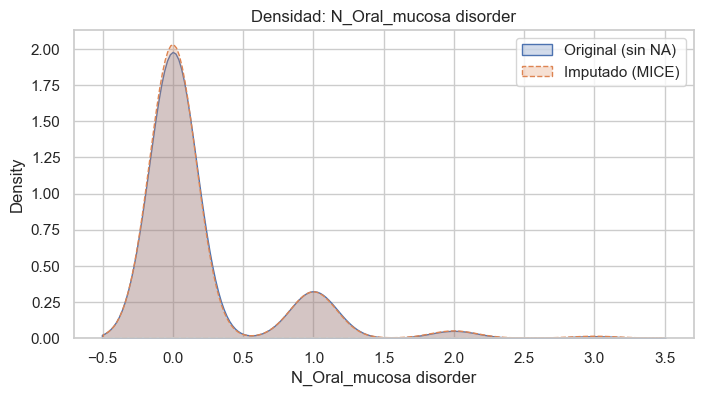

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 SA_Flow (ml/min)
   Media: 0.28 → 0.28
   Desviación estándar: 0.33 → 0.33
   KS test p-value: 1.0000 (Distribuciones similares)


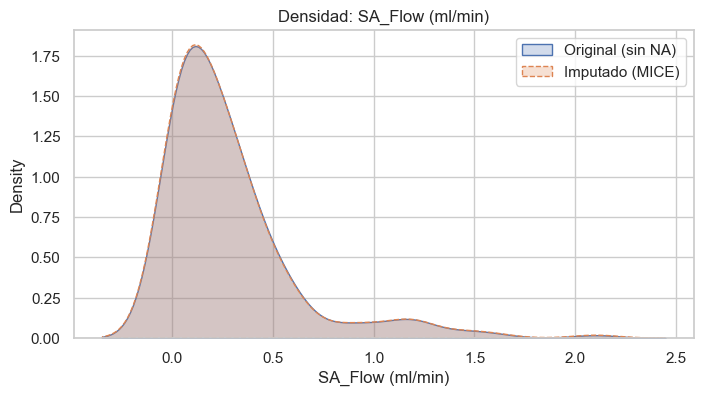

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 ST_Flow (ml/min)
   Media: 0.86 → 0.86
   Desviación estándar: 0.79 → 0.79
   KS test p-value: 1.0000 (Distribuciones similares)


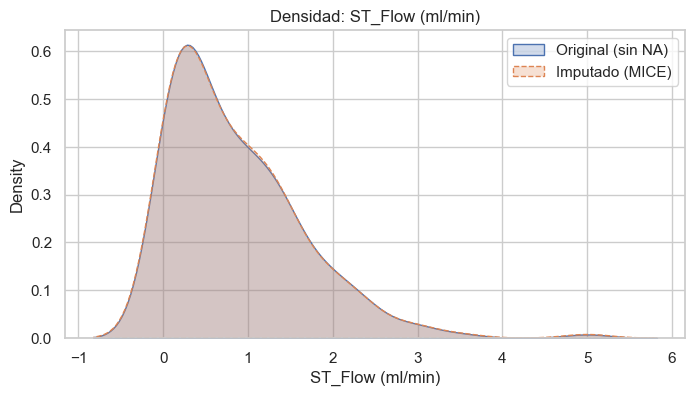

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 Menstrual_status
   Media: 0.26 → 0.26
   Desviación estándar: 0.44 → 0.44
   KS test p-value: 1.0000 (Distribuciones similares)


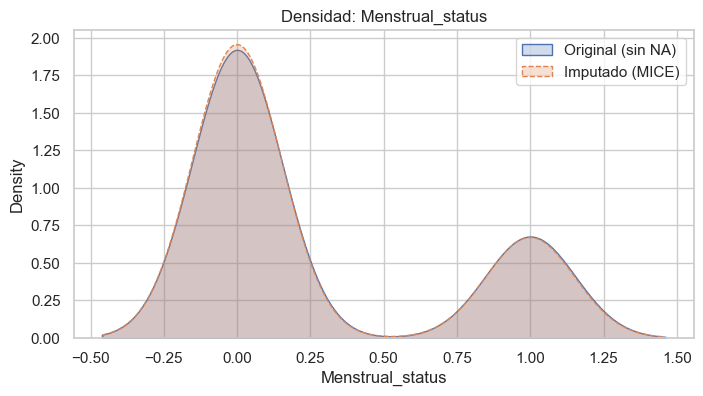


🔹 Sport
   Media: 1.77 → 1.77
   Desviación estándar: 1.64 → 1.63
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


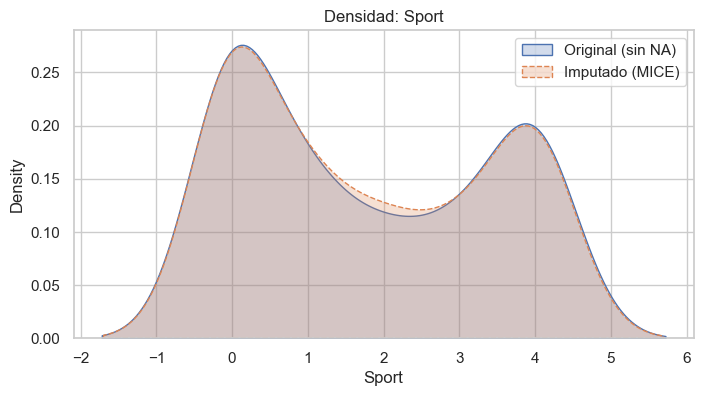

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 Special_Diet
   Media: 1.96 → 1.96
   Desviación estándar: 1.16 → 1.13
   KS test p-value: 1.0000 (Distribuciones similares)


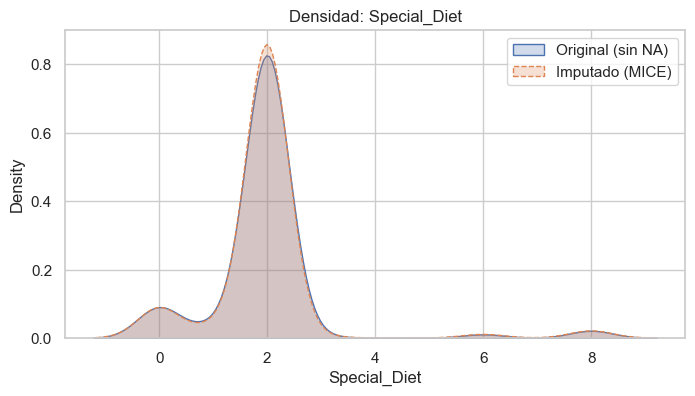


🔹 Sugar_Intake
   Media: 0.42 → 0.41
   Desviación estándar: 0.50 → 0.49
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


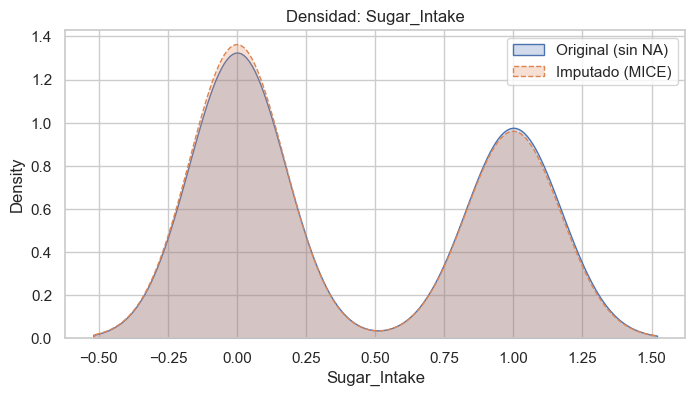


🔹 Sugar_between meals
   Media: 0.29 → 0.28
   Desviación estándar: 0.45 → 0.45
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


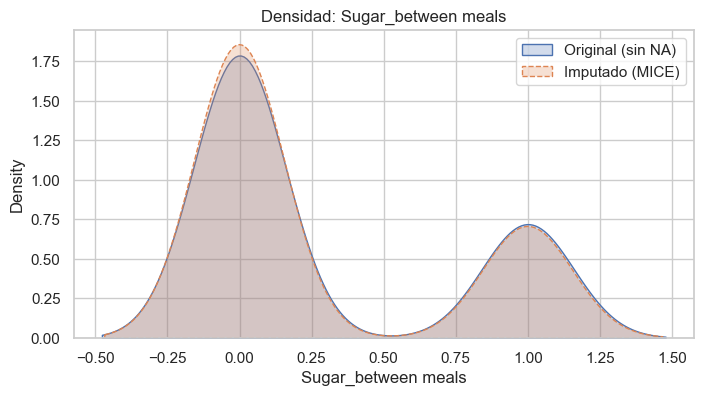


🔹 Smoking
   Media: 0.18 → 0.17
   Desviación estándar: 0.38 → 0.38
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


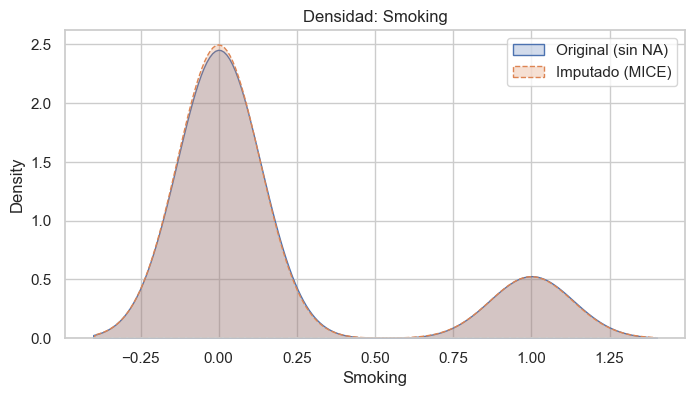


🔹 Caffeine
   Media: 0.68 → 0.68
   Desviación estándar: 0.47 → 0.47
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


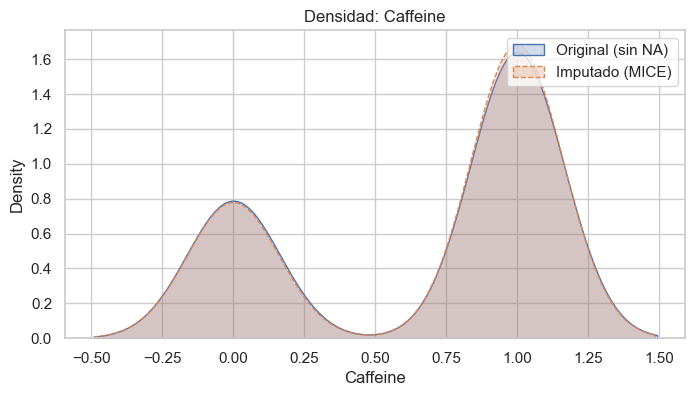

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 Alcohol_drinks
   Media: 0.44 → 0.44
   Desviación estándar: 0.50 → 0.50
   KS test p-value: 1.0000 (Distribuciones similares)


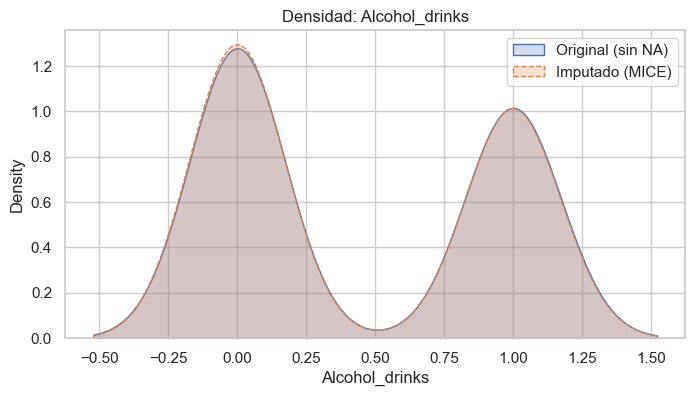


🔹 Cardiovascular
   Media: 0.43 → 0.42
   Desviación estándar: 0.50 → 0.50
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


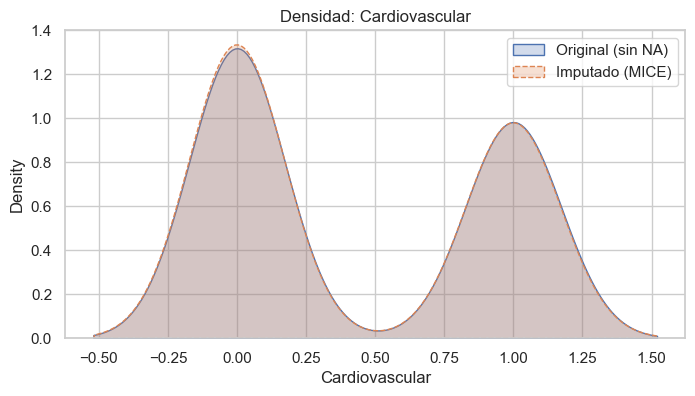


🔹 Neoplasia
   Media: 0.05 → 0.05
   Desviación estándar: 0.22 → 0.22
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


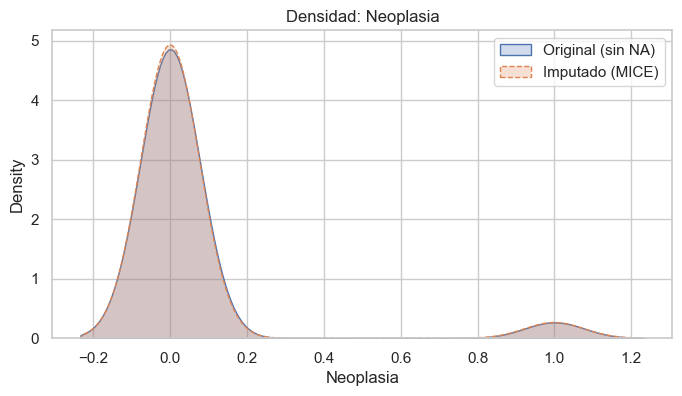

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 Gastrointestinal
   Media: 0.10 → 0.10
   Desviación estándar: 0.30 → 0.30
   KS test p-value: 1.0000 (Distribuciones similares)


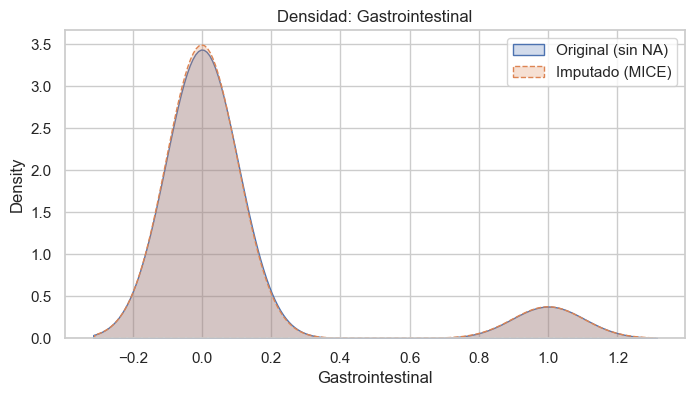


🔹 Diabetes
   Media: 0.25 → 0.24
   Desviación estándar: 0.43 → 0.43
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


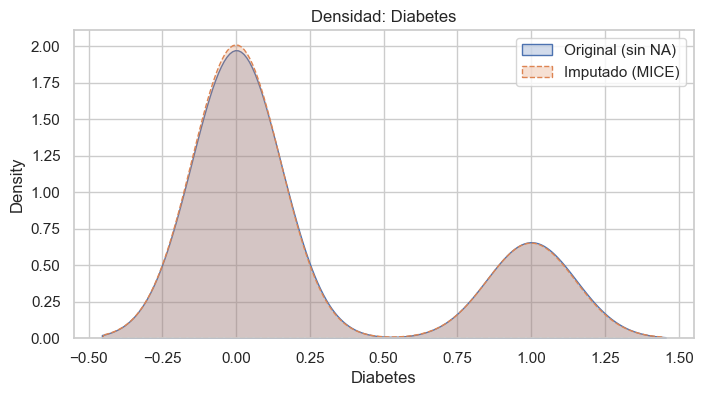


🔹 Autoinmunes
   Media: 0.63 → 0.63
   Desviación estándar: 0.49 → 0.48
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


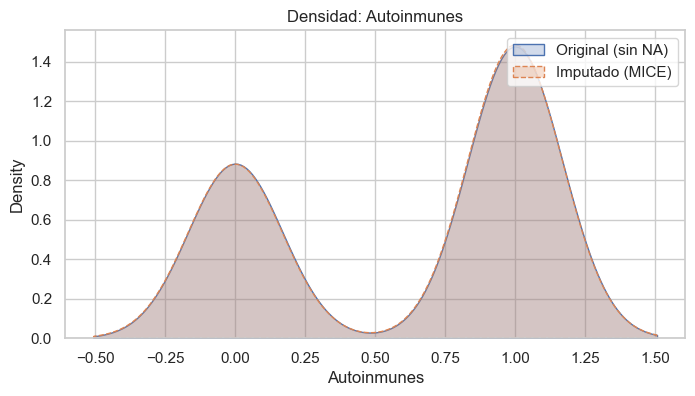


🔹 Immunosuppressants
   Media: 0.14 → 0.13
   Desviación estándar: 0.34 → 0.34
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


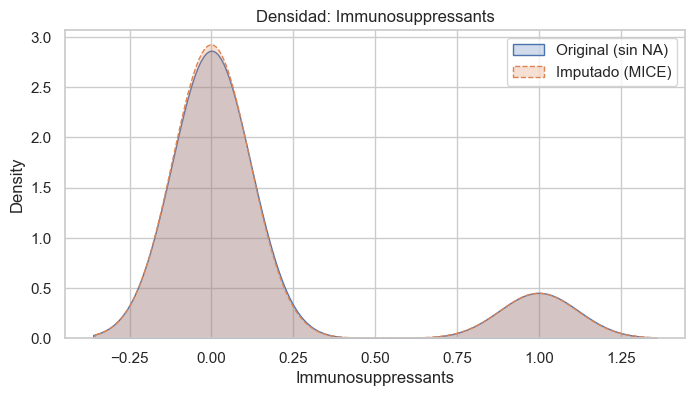


🔹 Corticosteroids
   Media: 0.05 → 0.05
   Desviación estándar: 0.21 → 0.21
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


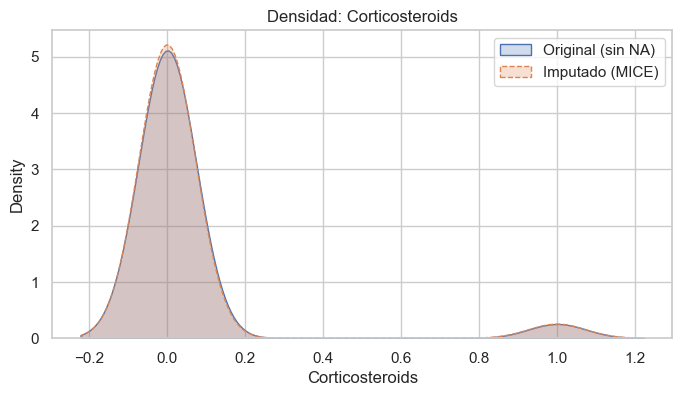

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 Hyposalivation_med
   Media: 0.16 → 0.16
   Desviación estándar: 0.37 → 0.37
   KS test p-value: 1.0000 (Distribuciones similares)


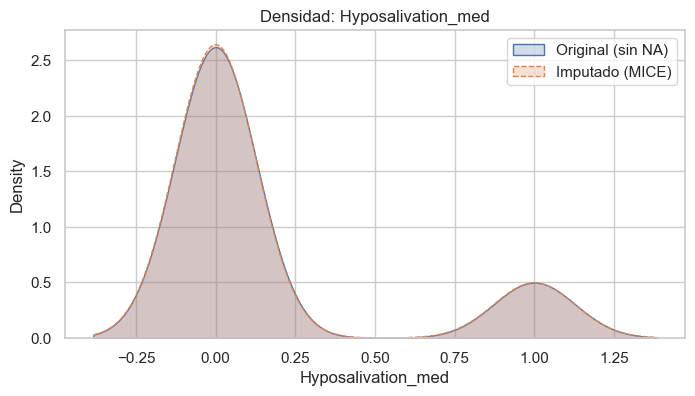


🔹 IPC
   Media: 2.36 → 2.39
   Desviación estándar: 1.12 → 1.08
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


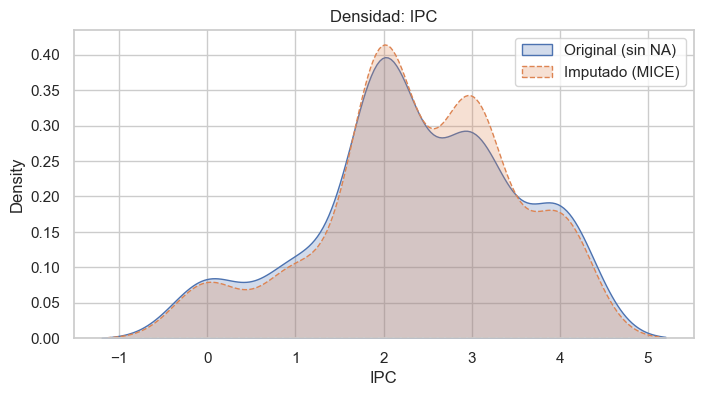

C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



🔹 SA_Hyposalivation
   Media: 0.62 → 0.62
   Desviación estándar: 0.49 → 0.49
   KS test p-value: 1.0000 (Distribuciones similares)


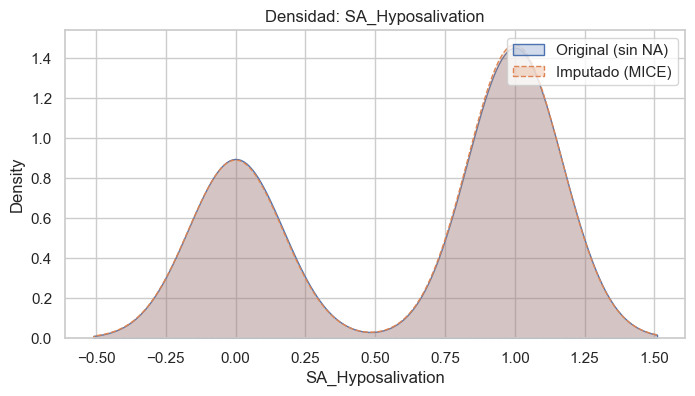


🔹 ST_Hyposalivation
   Media: 0.83 → 0.83
   Desviación estándar: 0.38 → 0.38
   KS test p-value: 1.0000 (Distribuciones similares)


C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Kristina\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


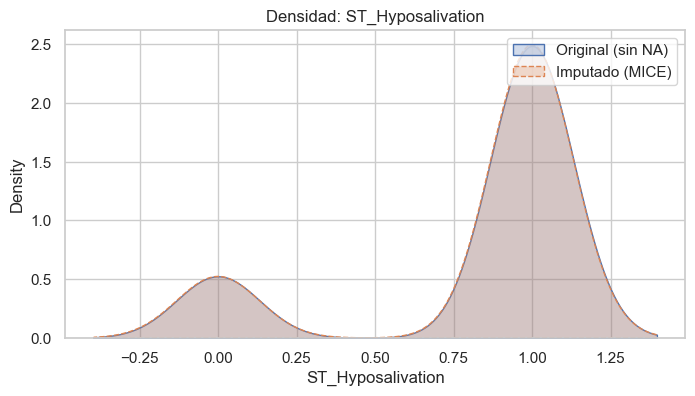

In [153]:
print("=== Comparación variables numéricas ===")
for var in vars_numericas:
    if var not in data_limpio.columns or var not in data_imputada.columns:
        continue

    original = data_limpio[var].dropna()
    imputado = data_imputada[var]

    mean_orig = original.mean()
    mean_imp = imputado.mean()
    std_orig = original.std()
    std_imp = imputado.std()

    stat, p_value = ks_2samp(original, imputado)

    print(f"\n🔹 {var}")
    print(f"   Media: {mean_orig:.2f} → {mean_imp:.2f}")
    print(f"   Desviación estándar: {std_orig:.2f} → {std_imp:.2f}")
    print(f"   KS test p-value: {p_value:.4f} {'(Distribuciones similares)' if p_value > 0.05 else '⚠️ Posible diferencia'}")

    # Graficar densidad
    plt.figure(figsize=(8, 4))
    sns.kdeplot(original, label="Original (sin NA)", fill=True)
    sns.kdeplot(imputado, label="Imputado (MICE)", fill=True, linestyle='--')
    plt.title(f'Densidad: {var}')
    plt.legend()
    plt.show()


=== Comparación variables categóricas ===

🔹 Menstrual_status
                  Original  Imputado
Menstrual_status                    
0.0               0.739583  0.744898
1.0               0.260417  0.255102
Chi-cuadrado p-value: 0.9971 (Distribuciones similares)


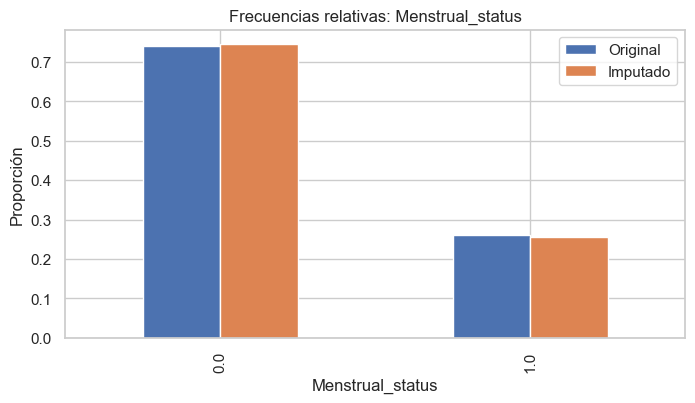


🔹 Sport
       Original  Imputado
Sport                    
0.0    0.354167  0.346939
1.0    0.161458  0.163265
2.0    0.109375  0.122449
3.0    0.114583  0.112245
4.0    0.260417  0.255102
Chi-cuadrado p-value: 0.9964 (Distribuciones similares)


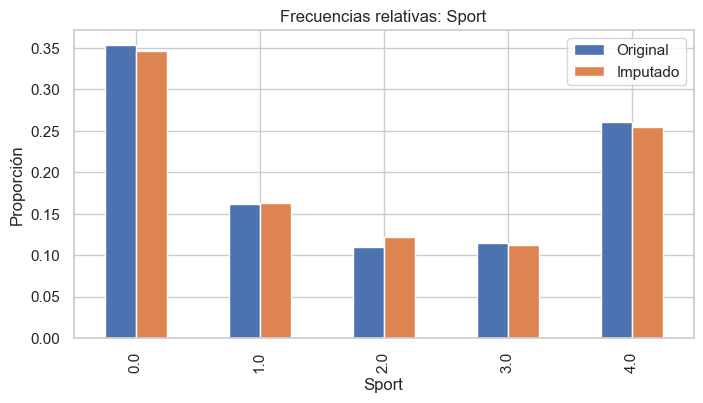


🔹 Special_Diet
              Original  Imputado
Special_Diet                    
0.0           0.090426  0.086735
1.0           0.031915  0.030612
2.0           0.840426  0.846939
3.0           0.005319  0.005102
6.0           0.010638  0.010204
8.0           0.021277  0.020408
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


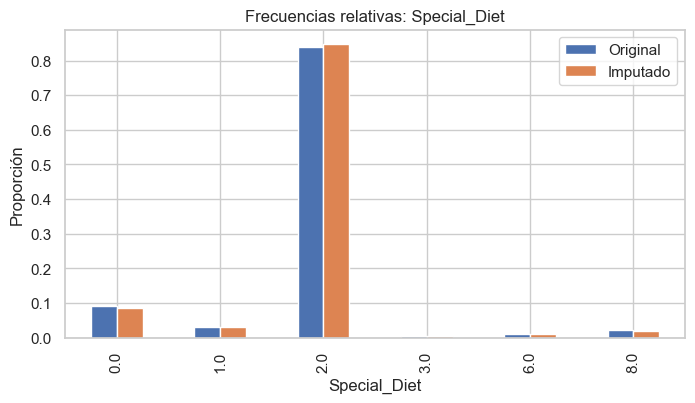


🔹 Sugar_Intake
              Original  Imputado
Sugar_Intake                    
0.0           0.575916  0.586735
1.0           0.424084  0.413265
Chi-cuadrado p-value: 0.9103 (Distribuciones similares)


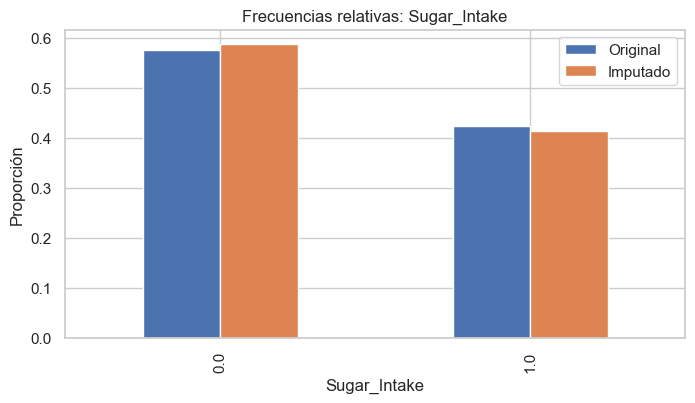


🔹 Sugar_between meals
                     Original  Imputado
Sugar_between meals                    
0.0                  0.712766   0.72449
1.0                  0.287234   0.27551
Chi-cuadrado p-value: 0.8872 (Distribuciones similares)


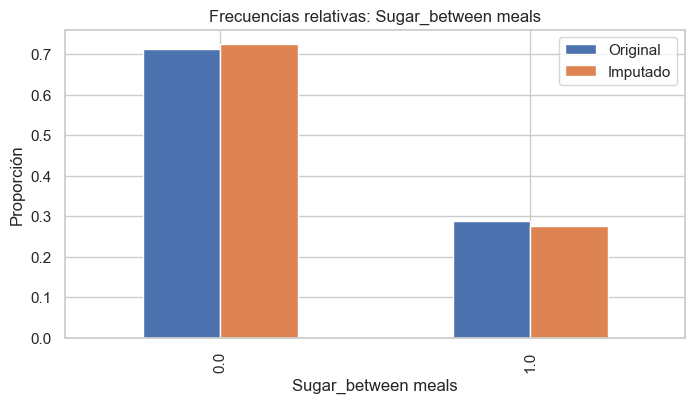


🔹 Smoking
         Original  Imputado
Smoking                    
0.0      0.822917  0.826531
1.0      0.177083  0.173469
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


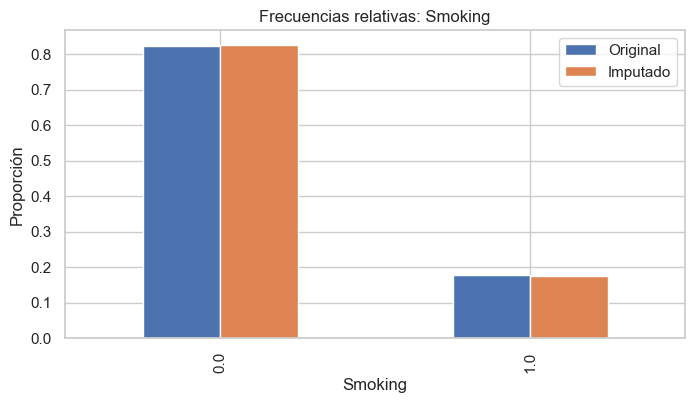


🔹 Caffeine
          Original  Imputado
Caffeine                    
0.0       0.324607  0.316327
1.0       0.675393  0.683673
Chi-cuadrado p-value: 0.9477 (Distribuciones similares)


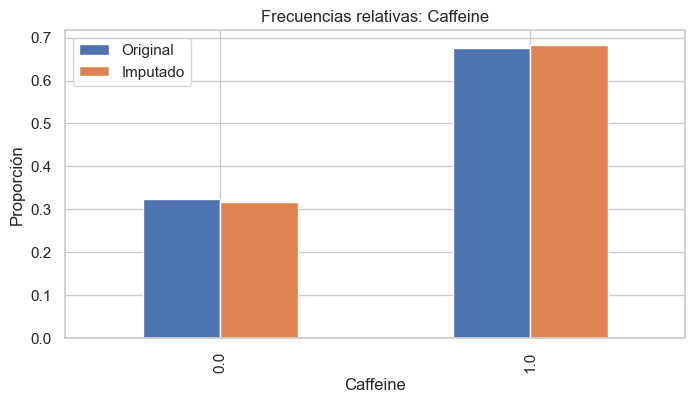


🔹 Alcohol_drinks
                Original  Imputado
Alcohol_drinks                    
0.0             0.557292  0.561224
1.0             0.442708  0.438776
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


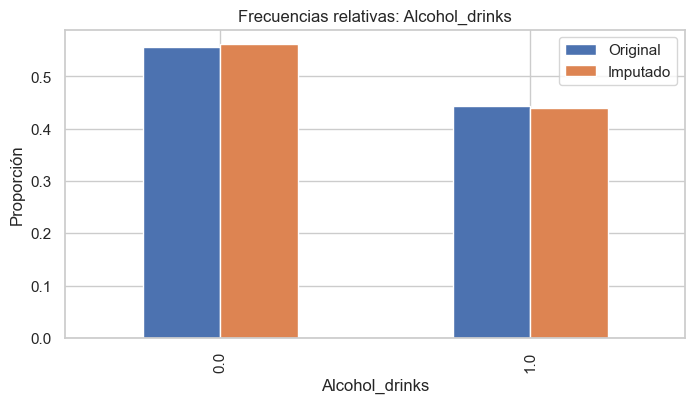


🔹 Cardiovascular
                Original  Imputado
Cardiovascular                    
0.0             0.572917  0.576531
1.0             0.427083  0.423469
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


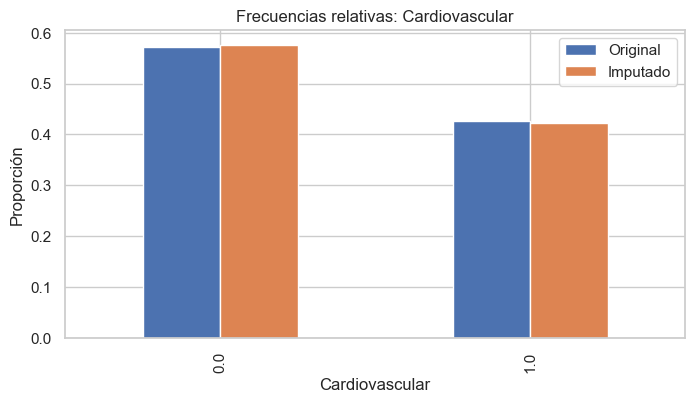


🔹 Neoplasia
           Original  Imputado
Neoplasia                    
0.0        0.947917   0.94898
1.0        0.052083   0.05102
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


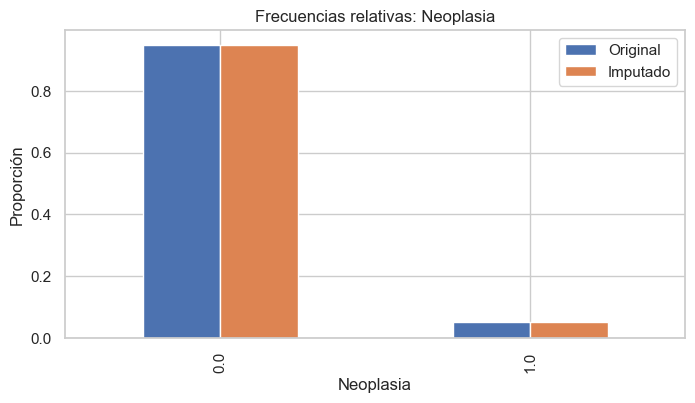


🔹 Gastrointestinal
                  Original  Imputado
Gastrointestinal                    
0.0               0.901042  0.903061
1.0               0.098958  0.096939
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


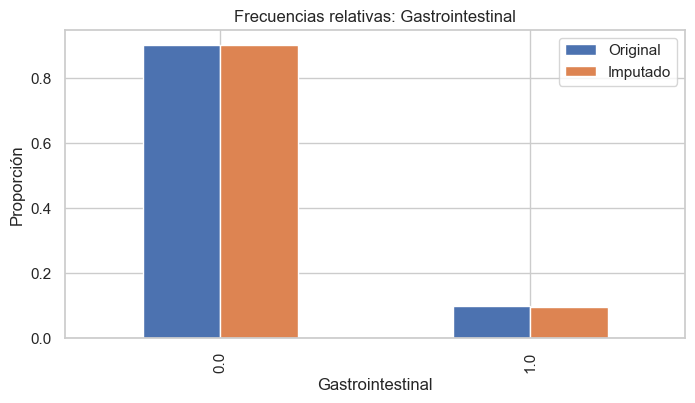


🔹 Diabetes
          Original  Imputado
Diabetes                    
0.0           0.75  0.755102
1.0           0.25  0.244898
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


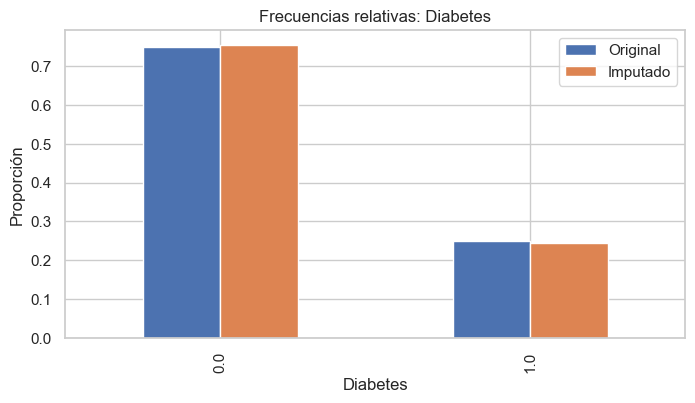


🔹 Autoinmunes
             Original  Imputado
Autoinmunes                    
0.0          0.374359  0.372449
1.0          0.625641  0.627551
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


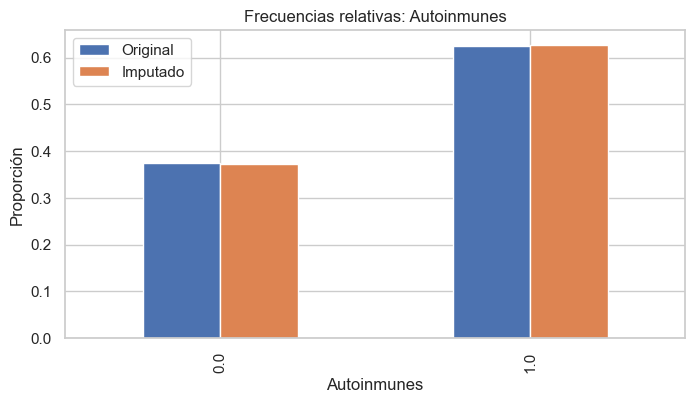


🔹 Immunosuppressants
                    Original  Imputado
Immunosuppressants                    
0.0                 0.863874  0.867347
1.0                 0.136126  0.132653
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


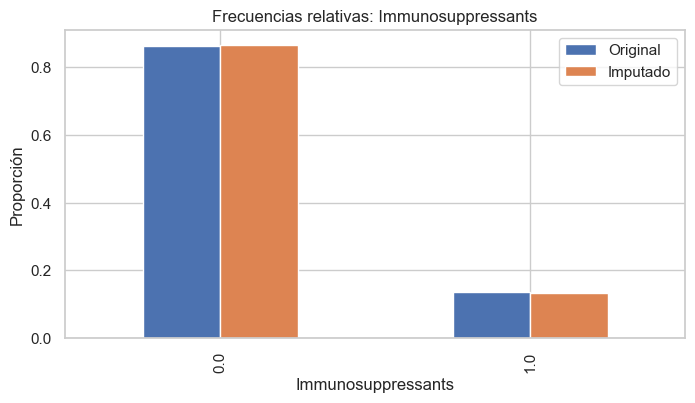


🔹 Corticosteroids
                 Original  Imputado
Corticosteroids                    
0.0               0.95288  0.954082
1.0               0.04712  0.045918
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


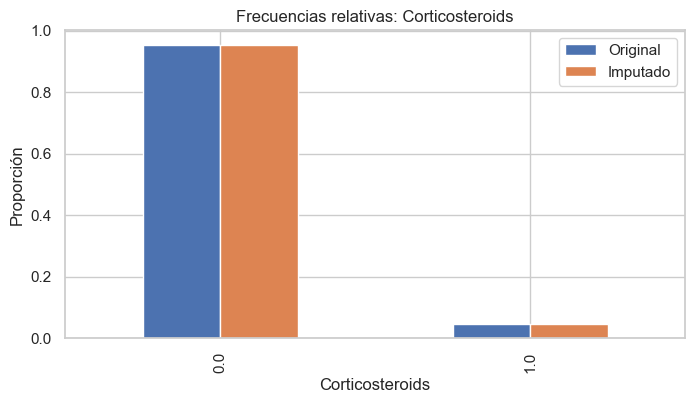


🔹 Hyposalivation_med
                    Original  Imputado
Hyposalivation_med                    
0.0                 0.840206  0.841837
1.0                 0.159794  0.158163
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


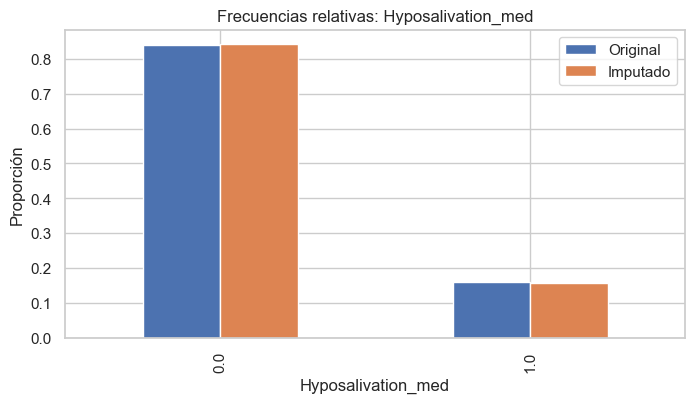


🔹 IPC
     Original  Imputado
IPC                    
0.0  0.079545  0.071429
1.0  0.096591  0.086735
2.0  0.380682  0.377551
3.0  0.267045  0.306122
4.0  0.176136  0.158163
Chi-cuadrado p-value: 0.9310 (Distribuciones similares)


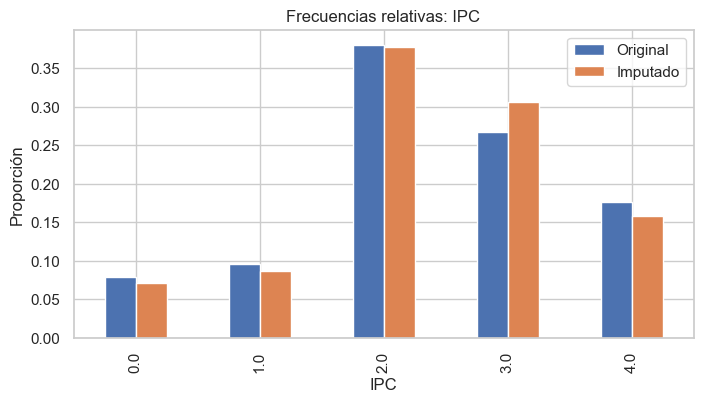


🔹 SA_Hyposalivation
                   Original  Imputado
SA_Hyposalivation                    
0.0                0.381443  0.377551
1.0                0.618557  0.622449
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


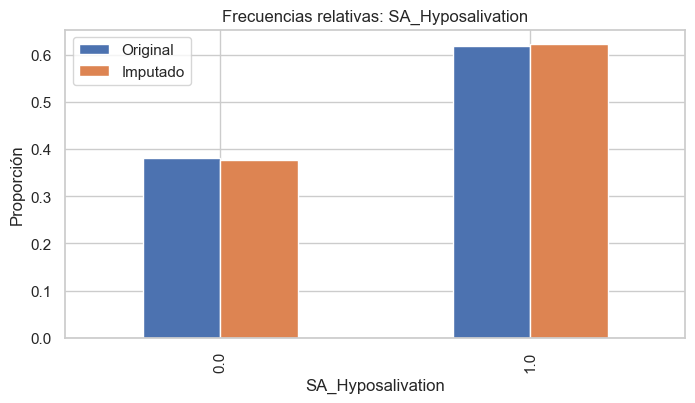


🔹 ST_Hyposalivation
                   Original  Imputado
ST_Hyposalivation                    
0.0                0.174359  0.173469
1.0                0.825641  0.826531
Chi-cuadrado p-value: 1.0000 (Distribuciones similares)


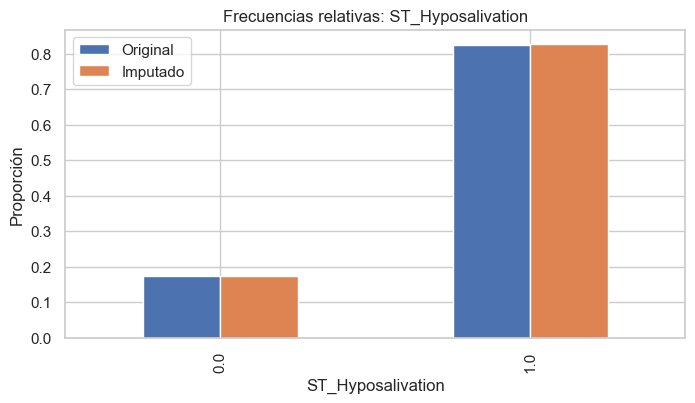

In [154]:
print("\n=== Comparación variables categóricas ===")
for var in DISCRETOS:
    if var not in data_limpio.columns or var not in data_imputada.columns:
        continue

    freq_orig = data_limpio[var].value_counts(dropna=True).sort_index()
    freq_imp = data_imputada[var].value_counts(dropna=True).sort_index()

    df_freq = pd.DataFrame({
        'Original': freq_orig / freq_orig.sum(),
        'Imputado': freq_imp / freq_imp.sum()
    }).fillna(0)

    categorias_union = sorted(set(freq_orig.index) | set(freq_imp.index))
    tabla_contingencia = pd.DataFrame({
        'Original': [freq_orig.get(cat, 0) for cat in categorias_union],
        'Imputado': [freq_imp.get(cat, 0) for cat in categorias_union]
    })

    chi2, p, dof, ex = chi2_contingency(tabla_contingencia.T)

    print(f"\n🔹 {var}")
    print(df_freq)
    print(f"Chi-cuadrado p-value: {p:.4f} {'(Distribuciones similares)' if p > 0.05 else '⚠️ Posible diferencia'}")

    df_freq.plot(kind='bar', figsize=(8,4))
    plt.title(f'Frecuencias relativas: {var}')
    plt.ylabel('Proporción')
    plt.show()

In [155]:
data_imputada['Sjogren'] = data_limpio['Sjogren']

<Axes: >

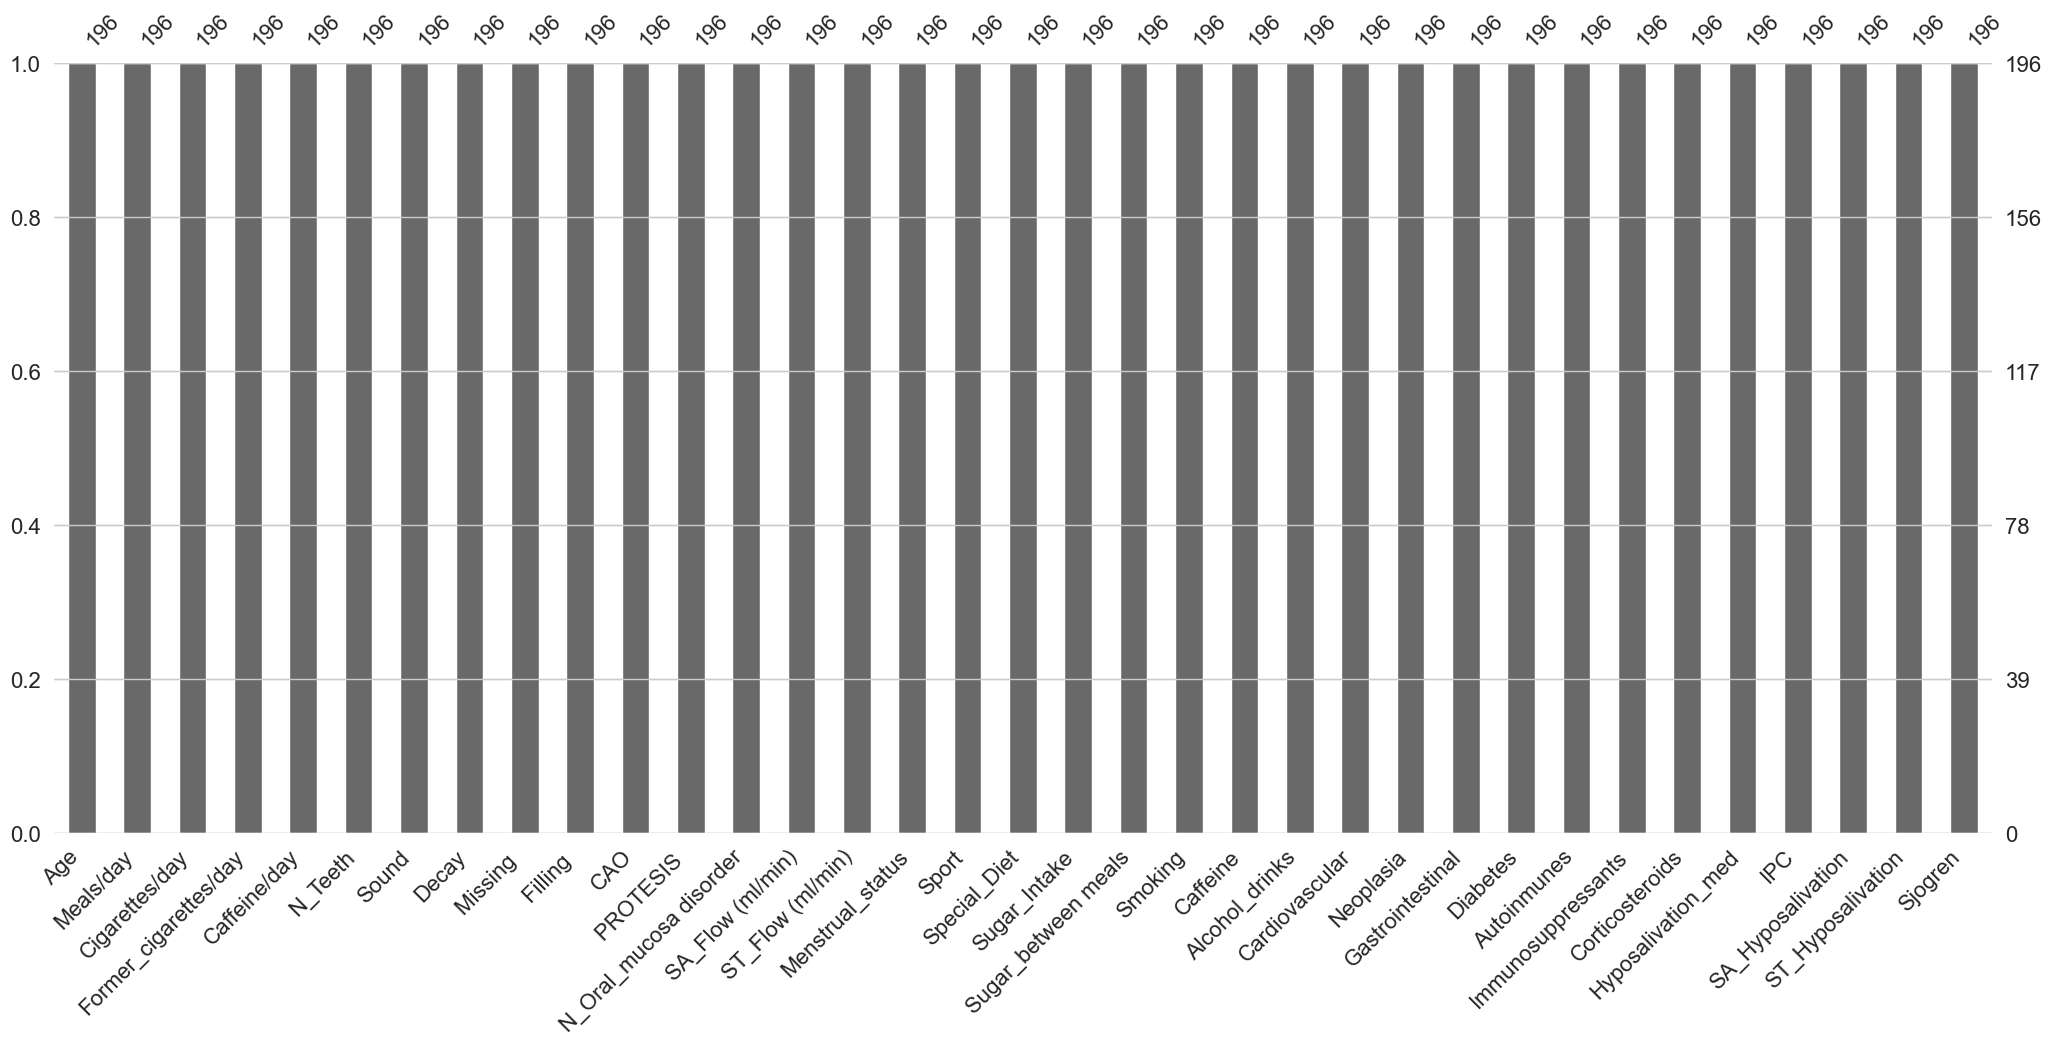

In [156]:
msno.bar(data_imputada)

In [157]:
data_imputada.to_csv('ssj_mice_imputation+sjogren+hypomed.csv', index=False)

#### 3.1.3. Detección y tratamiento de valores atípicos (outliers)

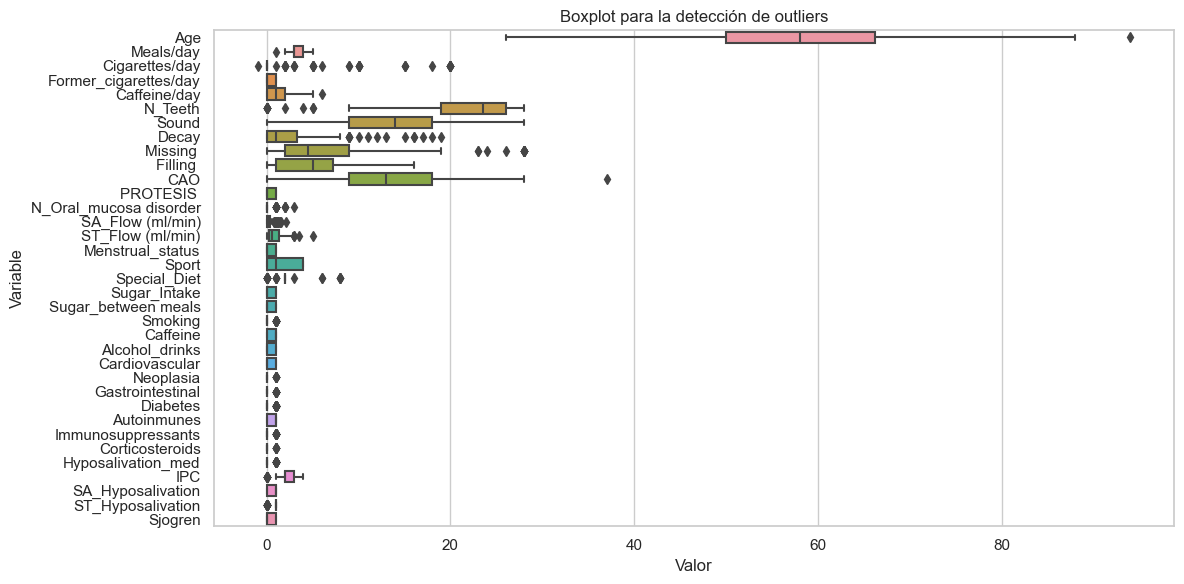

📊 Número de outliers por variable:
Age                        1
Meals/day                  1
Cigarettes/day            38
Former_cigarettes/day      0
Caffeine/day               1
N_Teeth                   15
Sound                      0
Decay                     15
Missing                   15
Filling                    0
CAO                        1
PROTESIS                   0
N_Oral_mucosa disorder    31
SA_Flow (ml/min)          16
ST_Flow (ml/min)           4
Menstrual_status           0
Sport                      0
Special_Diet              30
Sugar_Intake               0
Sugar_between meals        0
Smoking                   34
Caffeine                   0
Alcohol_drinks             0
Cardiovascular             0
Neoplasia                 10
Gastrointestinal          19
Diabetes                  48
Autoinmunes                0
Immunosuppressants        26
Corticosteroids            9
Hyposalivation_med        31
IPC                       14
SA_Hyposalivation          0
ST_Hypos

In [158]:
# Seleccionar todas las columnas numéricas (excluye CLASE si no es numérica)
variables_numericas = data_imputada.select_dtypes(include='number').columns.tolist()
if 'CLASE' in variables_numericas:
    variables_numericas.remove('CLASE')

# 1. Boxplots horizontales para todas las variables numéricas
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_imputada[variables_numericas], orient='h')
plt.title("Boxplot para la detección de outliers")
plt.xlabel("Valor")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# 2. Cálculo del IQR y detección de outliers
Q1 = data_imputada[variables_numericas].quantile(0.25)
Q3 = data_imputada[variables_numericas].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (data_imputada[variables_numericas] < lower_bound) | (data_imputada[variables_numericas] > upper_bound)
outliers_count = outliers.sum()

print("📊 Número de outliers por variable:")
print(outliers_count)

In [159]:
# Filas (pacientes) que tienen al menos un outlier en alguna variable
pacientes_outliers = data_imputada[outliers.any(axis=1)]

print(f"Número total de pacientes con outliers: {pacientes_outliers.shape[0]}")

Número total de pacientes con outliers: 169


### 3.3. Reducción de datos <a name="reduccion-datos"></a>  

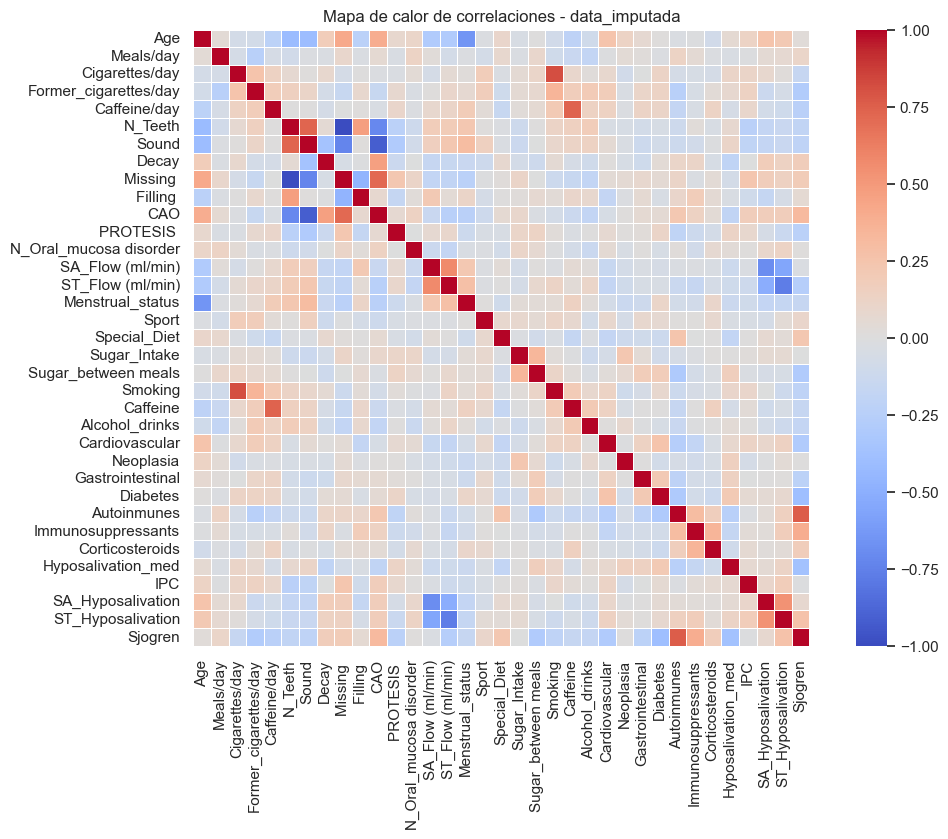

In [160]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_imputada.corr(),  # Matriz de correlación
            annot=False,             # Mostrar valores numéricos
            fmt=".2f",              # Formato decimal
            cmap="coolwarm",        # Paleta de colores
            cbar=True,              # Barra de color
            square=True,            # Celdas cuadradas
            linewidths=0.5)         # Separadores entre celdas

plt.title("Mapa de calor de correlaciones - data_imputada")
plt.show()

In [161]:
# Matriz de correlación
corr_matrix = data_imputada.corr()

# Poner a cero la diagonal para evitar auto-correlación
np.fill_diagonal(corr_matrix.values, 0)

# Umbral
threshold = 0.6

# Obtener pares con correlación fuerte (positiva o negativa)
strong_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > threshold:
            strong_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], corr_val))

# Mostrar resultado
for var1, var2, corr_val in strong_pairs:
    print(f"{var1} <-> {var2}: correlación = {corr_val:.3f}")

Age <-> Menstrual_status: correlación = -0.654
Cigarettes/day <-> Smoking: correlación = 0.820
Caffeine/day <-> Caffeine: correlación = 0.738
N_Teeth <-> Sound: correlación = 0.727
N_Teeth <-> Missing : correlación = -1.000
N_Teeth <-> CAO: correlación = -0.711
Sound <-> Missing : correlación = -0.727
Sound <-> CAO: correlación = -0.915
Missing  <-> CAO: correlación = 0.711
SA_Flow (ml/min) <-> SA_Hyposalivation: correlación = -0.692
ST_Flow (ml/min) <-> ST_Hyposalivation: correlación = -0.772
Autoinmunes <-> Sjogren: correlación = 0.763


In [162]:
cols_a_eliminar = [
    'Cigarettes/day',
    'Caffeine/day',
    'SA_Hyposalivation',
    'ST_Hyposalivation',
    'Decay',
    'Missing',  
    'Filling',
    'Autoinmunes',
    'Immunosuppressants'
]

# limpia los nombres
data_imputada.columns = data_imputada.columns.str.strip()

# Ahora sí puedes eliminar sin problema:
data_imputada = data_imputada.drop(columns=[col.strip() for col in cols_a_eliminar])

In [163]:
data_imputada.insert(0, 'SubjectID', db_ssj['SubjectID'].values)
data_imputada.to_excel('data_limpio.xlsx', index=False)

In [164]:
data_imputada.head()

,SubjectID,Age,Meals/day,Former_cigarettes/day,N_Teeth,Sound,CAO,PROTESIS,N_Oral_mucosa disorder,SA_Flow (ml/min),...,Caffeine,Alcohol_drinks,Cardiovascular,Neoplasia,Gastrointestinal,Diabetes,Corticosteroids,Hyposalivation_med,IPC,Sjogren
0,SSVM001,60,2,0,23,12,16,0,0,0.01,...,1,0,1,0,0,0,0,0,3,1
1,SSVM002,42,3,0,28,21,7,0,0,0.10,...,1,1,0,0,0,0,0,0,1,1
2,SSVM003,46,4,0,26,10,18,0,0,0.13,...,1,1,0,0,0,0,1,0,3,1
3,SSVM004,70,4,1,0,0,28,1,0,0.20,...,0,0,0,0,0,0,0,0,3,1
4,SSVM005,48,5,0,19,9,19,0,0,0.02,...,0,0,0,0,0,0,0,0,4,1


In [165]:
data_imputada.shape

(196, 27)

Objetivo: Ver si tus pacientes se agrupan por edad o tabaco en lugar de por Sjögren.

**Paso 1: Ejecuta el PCA**
Obtienes tus coordenadas: PC1, PC2, PC3 para cada paciente.

**Paso 2: El "Escaneo" (Barrido de Asociaciones)**
Ahora, coges el vector de valores del PC1 y calculas su correlación (o asociación) con TODAS tus otras variables una por una.

El ordenador hará esto internamente:
	¿Cuánto se parece el PC1 a la variable Age? → Correlación: 0.75 (¡Muy alta!)
	¿Cuánto se parece el PC1 a la variable Sugar_Intake? → Correlación: 0.02 (Nada).
	¿Cuánto se parece el PC1 a la variable Smoking? → Correlación: 0.10 (Baja).
	¿Cuánto se parece el PC1 a la variable Group (Sjögren)? → Correlación: 0.30.

**Paso 3: El Ranking de "Culpables"**

Ordenas esas correlaciones de mayor a menor.
Escenario A (Ideal): La variable que más correlaciona con PC1 es Group (Sjögren).
Conclusión: Tus datos se separan principalmente por la enfermedad. ¡Genial!

Escenario B (Confounding detectado): La variable que más correlaciona con PC1 es Age (0.75) y el Group está mucho más abajo (0.30).
Conclusión: "Sin yo saber nada, el análisis me dice que la fuerza principal que mueve estos datos es la Edad, no el Sjögren".

**Paso 4: AHORA pintas el gráfico**
Solo ahora, que el ranking te ha dicho que la Age es la ganadora (la que más se parece al PC1), pintas el Scatter Plot coloreado por Age.
Verás un degradado perfecto de jóvenes a viejos cruzando el gráfico.
Confirmas visualmente lo que el número te dijo.


In [81]:
data_imputada.head()

,Age,Meals/day,Former_cigarettes/day,N_Teeth,Sound,CAO,PROTESIS,N_Oral_mucosa disorder,SA_Flow (ml/min),ST_Flow (ml/min),...,Caffeine,Alcohol_drinks,Cardiovascular,Neoplasia,Gastrointestinal,Diabetes,Corticosteroids,Hyposalivation_med,IPC,Sjogren
0,60,2,0,23,12,16,0,0,0.01,0.9,...,1,0,1,0,0,0,0,0,3,1
1,42,3,0,28,21,7,0,0,0.10,1.2,...,1,1,0,0,0,0,0,0,1,1
2,46,4,0,26,10,18,0,0,0.13,0.8,...,1,1,0,0,0,0,1,0,3,1
3,70,4,1,0,0,28,1,0,0.20,0.6,...,0,0,0,0,0,0,0,0,3,1
4,48,5,0,19,9,19,0,0,0.02,0.6,...,0,0,0,0,0,0,0,0,4,1


In [82]:
data_imputada.shape

(196, 26)

In [83]:
# Requisitos: pandas, numpy, scikit-learn, matplotlib, seaborn, scipy
# pip install pandas numpy scikit-learn matplotlib seaborn scipy

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ---------- Funciones auxiliares ----------
def correlation_ratio(categories, measurements):
    """
    Correlation ratio (eta) between a categorical variable and a numeric variable.
    categories : array-like (categorical labels)
    measurements: array-like (numeric)
    Returns eta in [0,1]
    """
    categories = np.array(categories)
    measurements = np.array(measurements, dtype=float)
    if measurements.size == 0:
        return np.nan
    # remove nan pairs
    mask = ~np.isnan(measurements) & (categories != None)
    if mask.sum() == 0:
        return np.nan
    categories = categories[mask]
    measurements = measurements[mask]

    # unique categories
    labels, counts = np.unique(categories, return_counts=True)
    if labels.size == 0:
        return np.nan
    grand_mean = measurements.mean()
    ss_between = 0.0
    for lab in labels:
        group_vals = measurements[categories == lab]
        if group_vals.size == 0:
            continue
        ss_between += group_vals.size * (group_vals.mean() - grand_mean) ** 2
    ss_total = ((measurements - grand_mean) ** 2).sum()
    if ss_total == 0:
        return 0.0
    eta = np.sqrt(ss_between / ss_total)
    return eta

def safe_pearson(x, y):
    """Pearson correlation absolute value, handling constant arrays and nans."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan
    x2 = x[mask]
    y2 = y[mask]
    if np.std(x2) == 0 or np.std(y2) == 0:
        return 0.0
    return abs(pearsonr(x2, y2)[0])

# ---------- Asume: data_imputada es tu DataFrame ya imputado ----------
# data_imputada = pd.read_csv("...")  # si necesitas cargarlo
df = data_imputada.copy().drop(columns=["Sjogren"])  # usa el DataFrame que ya tienes

# Guardamos lista de columnas originales (por si luego añadimos PCs)
orig_cols = df.columns.tolist()

# Convertir datetimes a numéricos (opcional)
for col in df.select_dtypes(include=['datetime', 'datetime64[ns]']).columns:
    df[col] = df[col].astype('int64') / 1e9  # segundos desde epoch

# Seleccionar columnas numéricas para PCA.
# Nota: podrías querer excluir variables categóricas no numéricas del PCA.
# Aquí convertimos booleanos a 0/1 y categóricas a one-hot (opcional).
# Opción simple: hacer PCA solo sobre variables numéricas (recommended).
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) < 2:
    raise ValueError("No hay suficientes columnas numéricas en data_imputada para hacer PCA.")

X = df[numeric_cols].values.astype(float)

# Estandarizar antes de PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA y extracción de las 3 primeras componentes
pca = PCA(n_components=3)
pcs = pca.fit_transform(X_scaled)
# Añadimos PCs al DataFrame para plot y uso posterior
df['PC1'] = pcs[:, 0]
df['PC2'] = pcs[:, 1]
df['PC3'] = pcs[:, 2]

# ---------- Escaneo de asociaciones: PC1 vs todas las variables ----------
assocs = []  # lista de dicts: variable, method, score

for col in orig_cols:
    if col not in df.columns:
        continue
    # saltar las columnas de PC que acabamos de crear
    if col in ('PC1', 'PC2', 'PC3'):
        continue

    series = df[col]
    # Si es numérica (int/float)
    if pd.api.types.is_numeric_dtype(series):
        score = safe_pearson(series.values, df['PC1'].values)
        method = 'pearson_numeric'
    else:
        nunique = series.nunique(dropna=True)
        if nunique == 2:
            # mapear a 0/1
            mapped = pd.factorize(series)[0].astype(float)  # devuelve 0/1...
            score = safe_pearson(mapped, df['PC1'].values)
            method = 'binary_pearson'
        elif nunique <= 1:
            score = np.nan
            method = 'constant'
        else:
            # variable categórica con >2 niveles: usar correlation ratio (eta)
            score = correlation_ratio(series.values, df['PC1'].values)
            method = 'correlation_ratio'
    assocs.append({'variable': col, 'method': method, 'score': float(np.nan_to_num(score, nan=np.nan))})

assocs_df = pd.DataFrame(assocs).sort_values('score', ascending=False).reset_index(drop=True)

# Mostrar ranking de las 10 primeras
print("Top 10 variables asociadas con PC1:")
display(assocs_df.head(10))

Top 10 variables asociadas con PC1:


,variable,method,score
0,Sound,pearson_numeric,0.838879
1,CAO,pearson_numeric,0.811646
2,N_Teeth,pearson_numeric,0.786255
3,Age,pearson_numeric,0.697634
4,Menstrual_status,pearson_numeric,0.550833
5,ST_Flow (ml/min),pearson_numeric,0.490427
6,SA_Flow (ml/min),pearson_numeric,0.398854
7,Caffeine,pearson_numeric,0.288993
8,Alcohol_drinks,pearson_numeric,0.272577
9,IPC,pearson_numeric,0.248959


* Sound (Dientes Sanos) - Score: 0.82
Por qué observarla: Es la Definición Matemática del PC1.
Qué verás: Es la variable con el score más alto. Al pintar el gráfico con ella, verás un degradado perfecto.
El mensaje: "Señores, matemáticamente, este conjunto de datos es un ranking de salud dental. A la izquierda bocas sanas, a la derecha bocas con mucha historia".
Nota: No hace falta pintar CAO o N_Teeth porque cuentan la misma historia que Sound.

* Age (Edad) - Score: 0.66
Por qué observarla: Es el Gran Confounder.
Qué verás: Un degradado muy claro, casi idéntico al de Sound.
El mensaje: "Como veis, la salud dental (Sound) y la edad (Age) son casi indistinguibles en este gráfico. El deterioro que vemos está dictado por el envejecimiento".
Nota: Menstrual_status (0.53) ignórala por ahora; es solo un "proxy" de la edad (menopausia vs fértil), Age es más limpia.

* Sjogren (El Target) - Score: 0.40
Por qué observarla: Es tu Objetivo Clínico.
Qué verás: Aquí viene lo interesante. Con un 0.40, la separación no será perfecta. Verás mezcla.
El mensaje: "¿Veis cómo los pacientes con Sjögren (rojo) tienden a estar en la zona de 'Pocos Dientes/Mucha Edad', pero hay mucha mezcla con los controles? Esto demuestra que 'a ojo' es difícil separarlos solo por el estado general".

* ST_Flow (Flujo Estimulado) - Score: 0.49
Por qué observarla: Es el Vínculo Funcional.
Qué verás: Tiene más correlación (0.49) que el propio Sjögren (0.40) y que el flujo en reposo (SA_Flow 0.37).
El mensaje: "Curiosamente, la falta de saliva estimulada (ST_Flow) se alinea mejor con el eje de deterioro dental que el propio diagnóstico. Esto sugiere que el daño dental físico está muy ligado a la capacidad funcional de las glándulas".

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Variables que quieres pintar
vars_to_plot = ["Sound", "Age", "Sjogren", "ST_Flow (ml/min)"]

# Definir la columna que controla la FORMA (debe estar en tu df)
shape_col = 'Sjogren'  # O 'Group', asegúrate de que existe en df

# Definir las formas: 0=Círculo ('o'), 1=Triángulo ('^')
# Si tu columna tiene 'Control'/'Sjogren' en texto, usa esas claves en el dict
custom_markers = {0: 'o', 1: '^'} 

for v in vars_to_plot:
    if v not in df.columns:
        print(f"Variable {v} no encontrada en el DataFrame. Saltando...")
        continue

    plt.figure(figsize=(10, 8))
    
    # Lógica para elegir paleta de colores (Numérica vs Categórica)
    if pd.api.types.is_numeric_dtype(df[v]):
        # Caso Numérico (ej. Age, Flow): Color continuo
        sns.scatterplot(
            data=df, 
            x='PC1', 
            y='PC2', 
            hue=v,                # Color según la variable (ej. Edad)
            style=shape_col,      # Forma según Sjögren
            markers=custom_markers, 
            palette='viridis',    # Paleta continua
            s=100,                # Tamaño de los puntos
            edgecolor='k', 
            linewidth=0.5,
            alpha=0.8
        )
        plt.title(f"PC1 vs PC2\nColor: {v} | Forma: {shape_col} (▲=Sjögren, ●=Control)")
        
    else:
        # Caso Categórico (ej. Sjogren, Sexo): Color discreto
        # Forzamos que sea categórica para que los colores salgan bien
        sns.scatterplot(
            data=df, 
            x='PC1', 
            y='PC2', 
            hue=df[v].astype('category'), # Color categórico
            style=shape_col,              # Forma según Sjögren
            markers=custom_markers,
            palette='tab10',              # Paleta discreta
            s=100, 
            edgecolor='k', 
            linewidth=0.5,
            alpha=0.8
        )
        plt.title(f"PC1 vs PC2\nColor: {v} | Forma: {shape_col}")

    # Ajustes estéticos
    plt.xlabel("PC1 (Eje Edad/Dientes)")
    plt.ylabel("PC2 (Eje Metabólico)")
    plt.grid(True, alpha=0.2)
    
    # Mover la leyenda fuera para que no tape los datos
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()

ValueError: Could not interpret value `Sjogren` for parameter `style`

<Figure size 1000x800 with 0 Axes>

La visualización del PCA confirma que la estructura dominante de los datos (Eje PC1) representa el envejecimiento biológico y oral: existe una superposición casi perfecta entre la edad avanzada, la pérdida de dientes sanos (Sound) y la disminución del flujo salival (ST_Flow).

In [ ]:
# Requisitos: pandas, numpy, scikit-learn, matplotlib, seaborn, scipy
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Funciones auxiliares ----------
def correlation_ratio(categories, measurements):
    categories = np.array(categories)
    measurements = np.array(measurements, dtype=float)
    mask = ~np.isnan(measurements)
    categories = categories[mask]
    measurements = measurements[mask]
    if measurements.size == 0:
        return np.nan
    labels = np.unique(categories)
    grand_mean = measurements.mean()
    ss_between = 0.0
    for lab in labels:
        group_vals = measurements[categories == lab]
        if group_vals.size == 0:
            continue
        ss_between += group_vals.size * (group_vals.mean() - grand_mean) ** 2
    ss_total = ((measurements - grand_mean) ** 2).sum()
    if ss_total == 0:
        return 0.0
    return float(np.sqrt(ss_between / ss_total))

def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    x2 = x[mask]
    y2 = y[mask]
    if np.std(x2) == 0 or np.std(y2) == 0:
        return 0.0, np.nan
    r, p = pearsonr(x2, y2)
    return float(r), float(p)

# ---------- Asegúrate de que `data_imputada` está en memoria ----------
df = data_imputada.copy()
df = df.drop(columns=["Sjogren"])

# ---------- Comprueba si hay PC1/PC2/PC3; si no, recalcula PCA ----------
if not all(c in df.columns for c in ['PC1','PC2','PC3']):
    print("PCs no encontradas en data_imputada → recalculando PCA sobre columnas numéricas...")
    # convertir datetimes si existen
    for col in df.select_dtypes(include=['datetime', 'datetime64[ns]']).columns:
        df[col] = df[col].astype('int64') / 1e9

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) < 2:
        raise ValueError("No hay suficientes columnas numéricas para calcular PCA. Revisa data_imputada.")
    X = df[numeric_cols].astype(float).values
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=3)
    pcs = pca.fit_transform(Xs)
    df['PC1'] = pcs[:,0]
    df['PC2'] = pcs[:,1]
    df['PC3'] = pcs[:,2]
    print(f"PCA recalculado. Varianza explicada PC1/PC2/PC3: {pca.explained_variance_ratio_[:3]*100}")
else:
    print("PC1/PC2/PC3 encontradas en el DataFrame; usando las columnas existentes.")

# ---------- Escaneo de asociaciones con PC2 ----------
target = df['PC2'].values
orig_cols = [c for c in data_imputada.columns]  # usar las columnas originales que tenías antes
assocs = []
for col in orig_cols:
    if col in ('PC1','PC2','PC3'):
        continue
    if col not in df.columns:
        continue
    series = df[col]
    if pd.api.types.is_numeric_dtype(series):
        r, p = safe_pearson(series.values, target)
        score = abs(r) if not np.isnan(r) else np.nan
        assocs.append({'variable': col, 'method': 'pearson_numeric', 'score': score, 'r': r, 'pvalue': p})
    else:
        nunique = series.nunique(dropna=True)
        if nunique == 2:
            mapped = pd.factorize(series)[0].astype(float)
            r, p = safe_pearson(mapped, target)
            score = abs(r) if not np.isnan(r) else np.nan
            assocs.append({'variable': col, 'method': 'binary_pearson', 'score': score, 'r': r, 'pvalue': p})
        elif nunique <= 1:
            assocs.append({'variable': col, 'method': 'constant', 'score': np.nan, 'r': np.nan, 'pvalue': np.nan})
        else:
            eta = correlation_ratio(series.values, target)
            assocs.append({'variable': col, 'method': 'correlation_ratio', 'score': eta, 'r': np.nan, 'pvalue': np.nan})

assocs_df = pd.DataFrame(assocs).sort_values('score', ascending=False).reset_index(drop=True)
print("Top 10 variables asociadas con PC2:")
display(assocs_df.head(10))

In [ ]:
# ---------- Selección de 4 variables a plotear ----------
# Opción: usar las 4 más asociadas
top4 = assocs_df['variable'].dropna().tolist()[:4]
print("Plotearé estas 4 variables (top4):", top4)

# Si prefieres forzar variables concretas (ej: Sound, Age, Sjogren, ST_Flow), sustituye la lista así:
# top4 = ["Sound","Age","Sjogren","ST_Flow (ml/min)"]

# ---------- Plots PC1 vs PC2 coloreados por cada variable en top4 ----------
for v in top4:
    if v not in df.columns:
        print(f"Advertencia: {v} no está en el DataFrame. Saltando.")
        continue

    plt.figure(figsize=(9,7))
    if pd.api.types.is_numeric_dtype(df[v]):
        sc = plt.scatter(df['PC1'], df['PC2'], c=df[v], cmap='viridis', s=45, edgecolor='k', linewidth=0.25)
        plt.colorbar(sc, label=v)
        plt.title(f"PC1 vs PC2 coloreado por {v}\n(score={assocs_df.loc[assocs_df.variable==v,'score'].values[0]:.3f})")
    else:
        hue_series = df[v].astype('category').cat.add_categories(['<NA>']).fillna('<NA>')
        sns.scatterplot(x='PC1', y='PC2', hue=hue_series, data=df, palette='tab10',
                        s=70, edgecolor='k', linewidth=0.3)
        plt.legend(title=v, bbox_to_anchor=(1.05,1), loc='upper left')
        plt.title(f"PC1 vs PC2 coloreado por {v}\n(score={assocs_df.loc[assocs_df.variable==v,'score'].values[0]:.3f})")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# ---------- Guardar ranking si quieres ----------
assocs_df.to_csv("ranking_asociaciones_PC2.csv", index=False)
print("Ranking completo guardado en 'ranking_asociaciones_PC2.csv'.")

